## Imports and functions

In [1]:
# -------------------------------------------------------------------
# 1) Standard library and environment utilities
# -------------------------------------------------------------------
import os
from datetime import datetime
from math import floor, log

# -------------------------------------------------------------------
# 2) Data / numerical analysis stack
# -------------------------------------------------------------------
import numpy as np
import pandas as pd

# -------------------------------------------------------------------
# 3) Plotting and visualization
# -------------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
from pylab import rcParams

# -------------------------------------------------------------------
# 4) Time series and statistics
# -------------------------------------------------------------------
from scipy import signal
from scipy.stats import norm, pearsonr, rankdata
from statsmodels.tsa import seasonal
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller, ccf, grangercausalitytests

# -------------------------------------------------------------------
# 5) Machine learning and preprocessing
# -------------------------------------------------------------------
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE, SelectFromModel
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# -------------------------------------------------------------------
# 6) BigQuery client dependencies (kept for compatibility with existing workflow)
# -------------------------------------------------------------------
# from google.cloud import bigquery, bigquery_storage
from pandas_gbq import to_gbq

# -------------------------------------------------------------------
# 7) Project utilities: move reusable helper functions to analysis_utils.py
# -------------------------------------------------------------------
from analysis_utils import (
    append_csv_to_dataframe,
    adjusted_r2,
    bic,
    ccf_funct,
    cross_correlate,
    detrender,
    dual_plot_corr,
    evaluate_model,
    forward_fill_increment,
    lagged_corr_plot,
    lin_model,
    plot_ccf_2,
    robust_r2_score,
    roll_apply_max_ccf,
    series_rel_plot,
    twinplot,
    LinearModelClass,
)

# Notebook plotting defaults
rcParams['figure.figsize'] = 12, 5

# Common plotting color scheme
color1 = 'black'
color2 = 'grey'
color3 = '#ffcc00'
f = 12 * 1e6

### Intro

In [2]:
directory_path = "C:/Users/illoi/Escritorio-2/00 - RETAIL INSIGHTS & ANALYTICS/01 - MARKET ANALYSIS/Data/US - Copy"
df_file_name = 'prov2.csv'
result_df_file_name = 'prov.csv'
sep = ','

df = pd.read_csv(os.path.join(directory_path, df_file_name), sep=sep, index_col=0, parse_dates=[0])
result_df = pd.read_csv(os.path.join(directory_path, result_df_file_name), sep=sep, index_col=0, parse_dates=[0])
df.head()

,CB CCI,Household PCE,Michigan CSI,PCE Durable goods Furnishings and durable household equipment,PCE,PCEDG PCE Durable goods,PCEDGC96 Real PCE Durable goods Chain-type,PCEPI PCE Chain-type,PCEPILFE PCE Excl Food and Energy Chain-Type,Real Households Final PCE,...,Real Usable Personal Income,Personal Consumption Expenditures per capita,Real Personal Consumption Expenditures per capita,Real Personal Consumption Expenditures per household,Consumption as share of GDP,roll_Consumption as share of GDP,roll_Consumption exp as share of GDP,Retail Sales Furniture & HF corr,Y,Y_infl_adj
1992-01-01,52.5,4109.625,67.5,121.980,4084.7,495.6,NaN,62.638,63.641,1607342.5,...,25967.688136,15.954993,28.278407,75.674101,0.641935,0.642253,0.643000,3699.0,3975.607143,2874.625555
1992-02-01,50.2,4109.625,68.8,121.980,4099.5,501.3,NaN,62.797,63.814,1607342.5,...,25953.929663,16.000568,28.297801,75.783899,0.641548,0.642516,0.643143,3759.0,3992.937500,2880.907287
1992-03-01,47.3,4109.625,76.0,121.980,4117.0,491.7,NaN,62.949,63.973,1607342.5,...,25957.001921,16.059669,28.300232,75.833836,0.642662,0.642504,0.643250,3997.0,4020.301587,2890.224002
1992-04-01,56.5,4109.625,77.2,122.968,4131.5,490.0,NaN,63.119,64.183,1616605.0,...,26001.846848,16.109056,28.326169,75.937146,0.642765,0.642619,0.643333,3981.0,4051.587500,2906.447274
1992-05-01,65.1,4109.625,79.2,122.968,4158.4,501.9,NaN,63.203,64.273,1616605.0,...,25990.949403,16.202541,28.429371,76.267435,0.642879,0.642933,0.643500,4109.0,4078.626263,2919.560675


### Adding the diff columns

In [3]:
original_cols = df.columns

In [4]:
diff_df = pd.DataFrame()
pct_df = pd.DataFrame()
roll_pct_df = pd.DataFrame()

diff_df = df.diff()
pct_df = df.pct_change(fill_method=None)
roll_pct_df = df.pct_change(fill_method=None).rolling(window=12, min_periods=1, center=True).mean()

diff_df.rename(columns=dict(zip(diff_df.columns,'diff_' + diff_df.columns)), inplace=True)
pct_df.rename(columns=dict(zip(pct_df.columns,'pct_chg_' + pct_df.columns)), inplace=True)
roll_pct_df.rename(columns=dict(zip(roll_pct_df.columns,'roll_pct_chg_' + roll_pct_df.columns)), inplace=True)

df = pd.concat([df, diff_df, pct_df, roll_pct_df], axis=1)

## HF modelling

### Adjustments and advanced modelling

#### Affordability adjustments

C:\Users\illoi\AppData\Local\Temp\ipykernel_44248\1651469774.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['HF Affordability index'] = (df['HF CPI'] / df['HF CPI'].iloc[0]) / (df['Consumer Price Index'] / df['Consumer Price Index'].iloc[0])


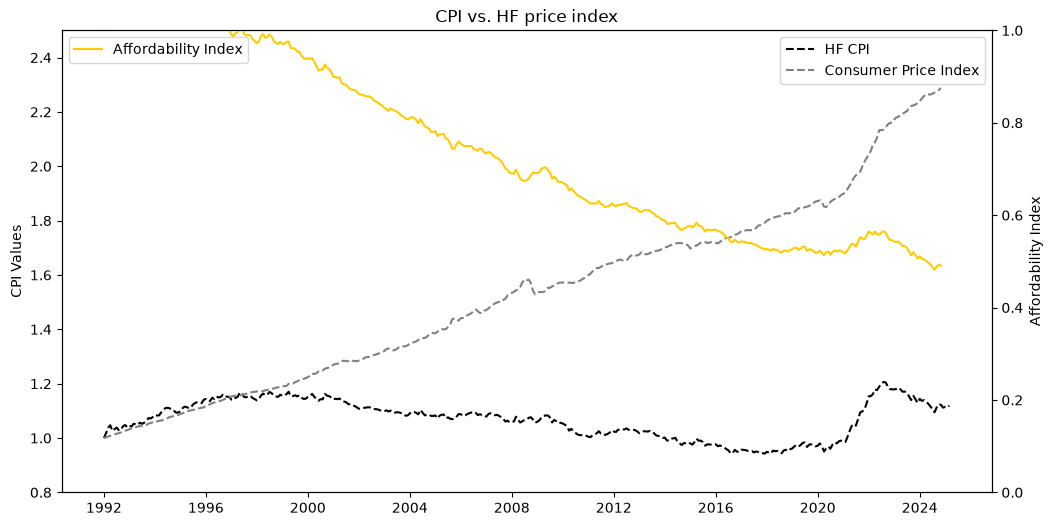

In [5]:
df['HF Affordability index'] = (df['HF CPI'] / df['HF CPI'].iloc[0]) / (df['Consumer Price Index'] / df['Consumer Price Index'].iloc[0])

# df[['HF CPI', 'Consumer Price Index']].plot(color=[color3, color1])
# ax2 = plt.twinx()
# ax2.plot(df['HF Affordability index'], color=color3, linestyle="--")

fig, ax1 = plt.subplots(figsize=(12,6))

# Plot HF CPI and CPI on primary y-axis
ax1.plot(df['HF CPI'] / df['HF CPI'].iloc[0], color=color1, label='HF CPI', linestyle="--")
ax1.plot(df['Consumer Price Index'] / df['Consumer Price Index'].iloc[0], color=color2, label='Consumer Price Index', linestyle="--")
ax1.set_ylim((0.8,2.5))
ax1.set_ylabel('CPI Values')
ax1.legend(loc='upper right')

# Create twin y-axis
ax2 = ax1.twinx()
ax2.plot(df['HF Affordability index'], color=color3, label='Affordability Index')
ax2.set_ylabel('Affordability Index')
ax2.legend(loc='upper left')
ax2.set_ylim((0,1))

plt.title('CPI vs. HF price index')
plt.show()

<Axes: >

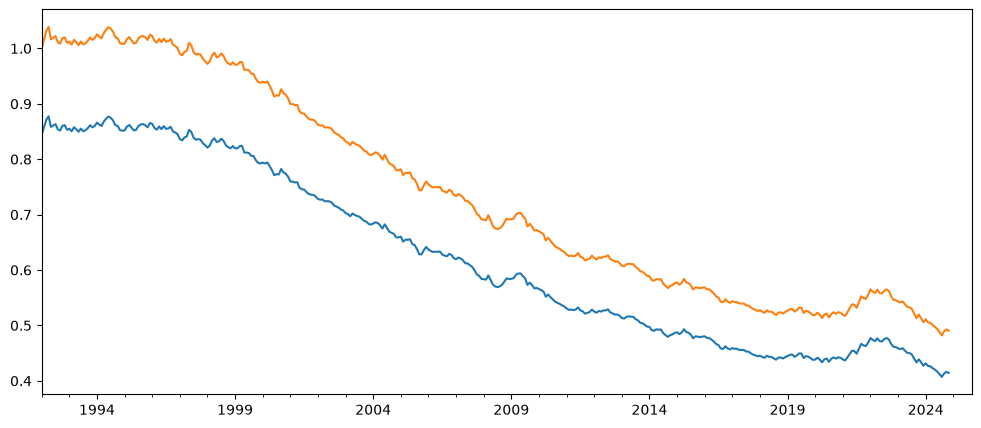

In [6]:
(df['HF CPI']/df['Consumer Price Index']).plot()
df['HF Affordability index'].plot()

<Axes: >

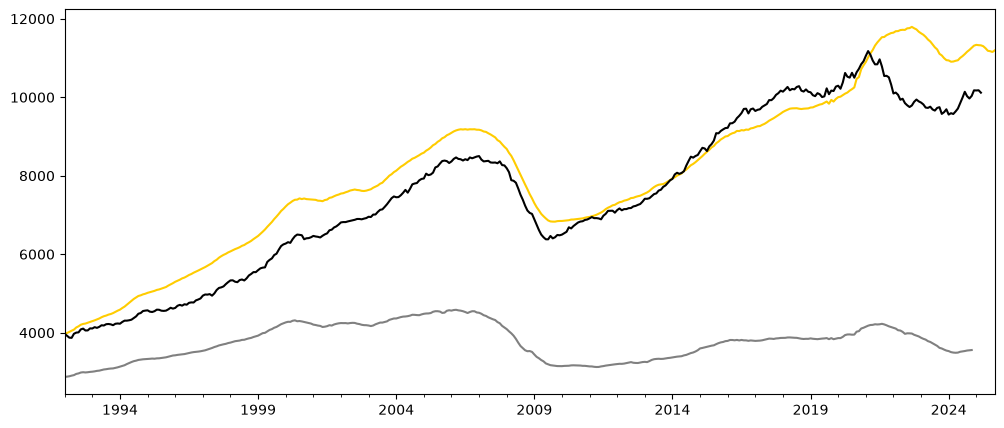

In [7]:
(df['Y']).plot(color=color3)
df['Y_infl_adj'].plot(color=color2)
(df['Y'] / (df['HF CPI'] / df['HF CPI'].iloc[0])).plot(color=color1)

C:\Users\illoi\AppData\Local\Temp\ipykernel_44248\1096345076.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Y_infl_adj_HF'] = df['Y_infl_adj']/df['HF Affordability index'] ** (0.5)


<Axes: >

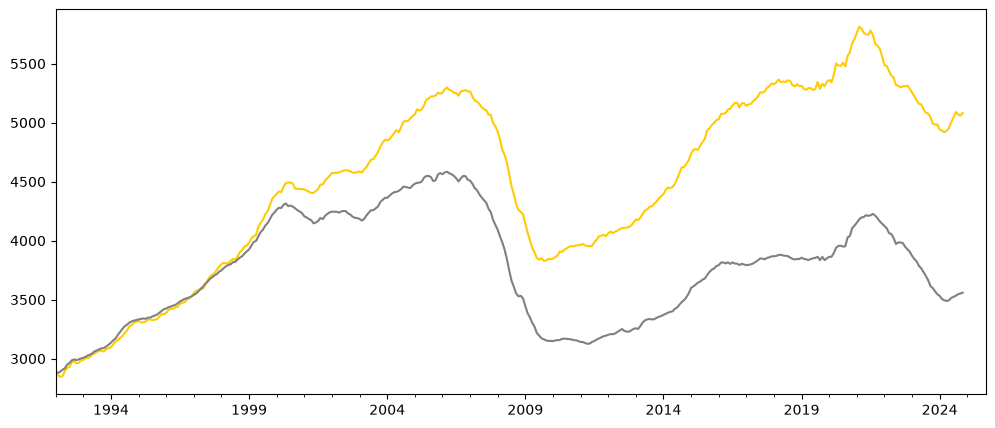

In [8]:
df['Y_infl_adj_HF'] = df['Y_infl_adj']/df['HF Affordability index'] ** (0.5)
df['Y_infl_adj_HF'].plot(color=color3)
df['Y_infl_adj'].plot(color=color2)

PearsonRResult(statistic=np.float64(0.7195210627802167), pvalue=np.float64(5.508763990870909e-62))

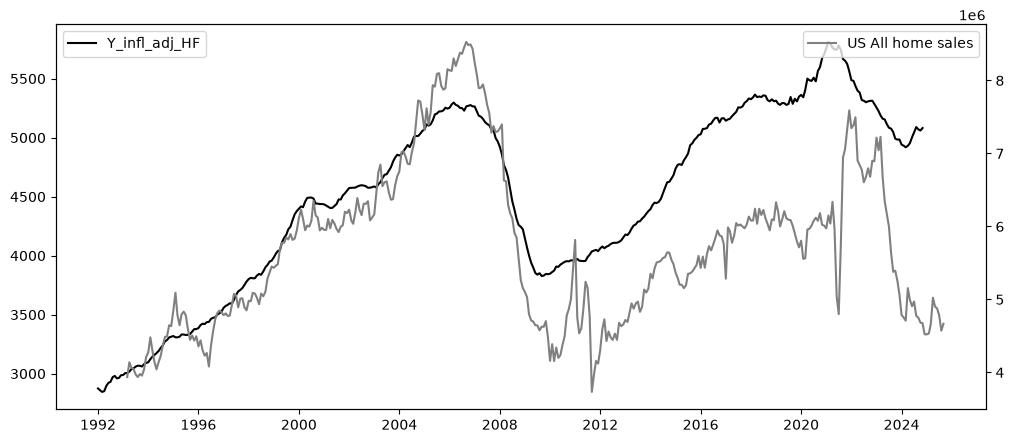

In [9]:
dual_plot_corr(df['Y_infl_adj_HF'], df['US All home sales'].shift(14))

<Axes: xlabel='Y_infl_adj_HF', ylabel='US All home sales'>

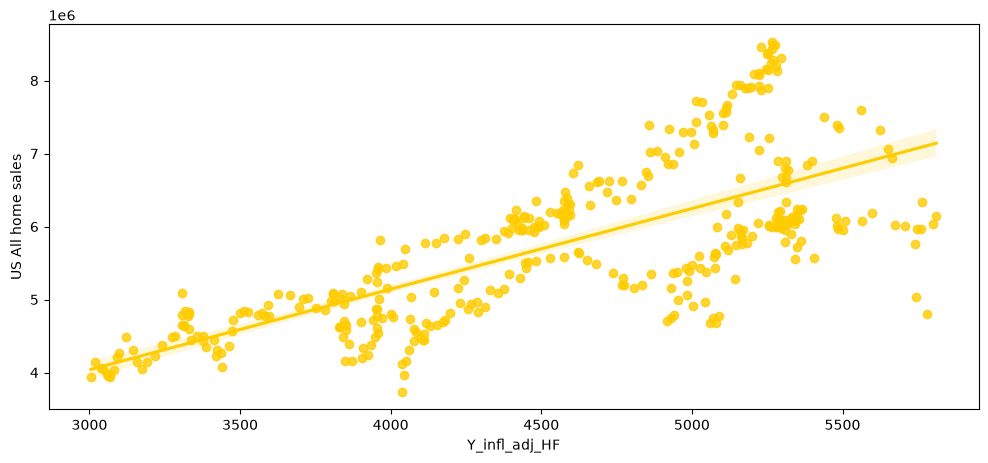

In [10]:
sns.regplot(x=df['Y_infl_adj_HF'], y=df['US All home sales'].shift(14), color=color3)

PearsonRResult(statistic=np.float64(0.4644279038838825), pvalue=np.float64(6.915365991725524e-22))

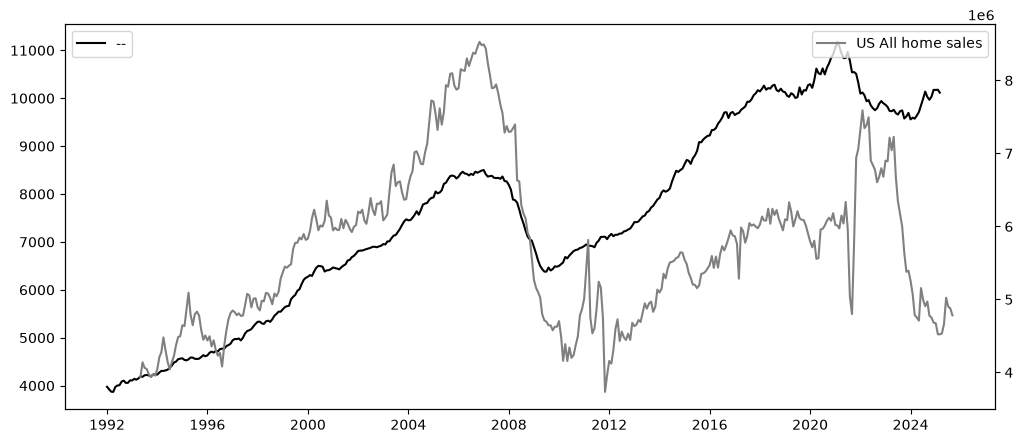

In [11]:
dual_plot_corr(df['Y'] / (df['HF CPI'] / df['HF CPI'].iloc[0]), df['US All home sales'].shift(16))

<Axes: ylabel='US All home sales'>

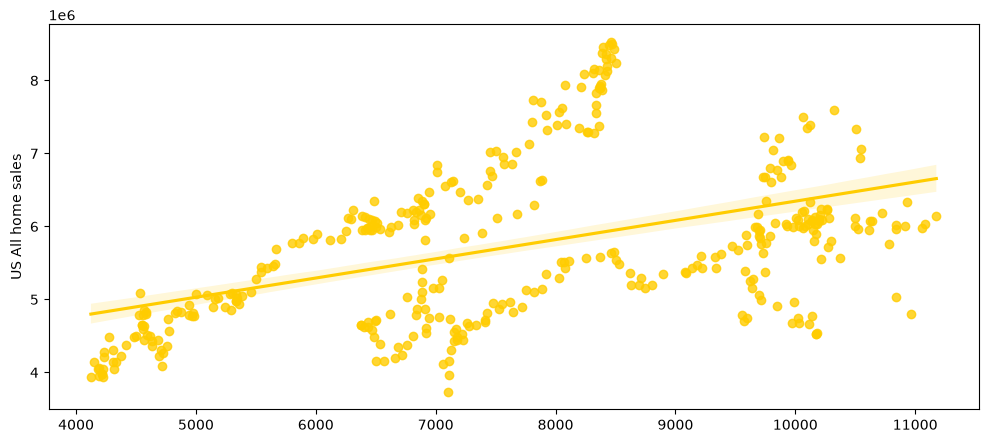

In [12]:
sns.regplot(x=df['Y'] / (df['HF CPI'] / df['HF CPI'].iloc[0]), y=df['US All home sales'].shift(14), color=color3)

#### Experiments

<Axes: >

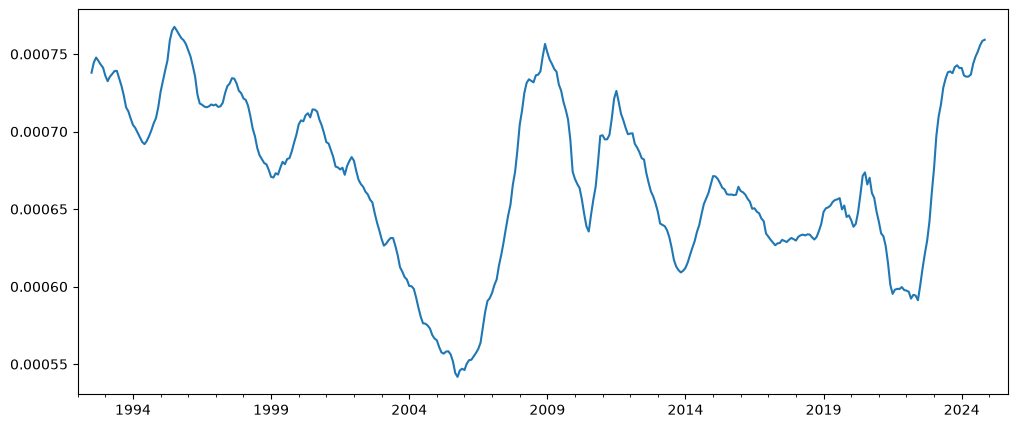

In [13]:
(df['Y_infl_adj'] / df['US All home sales'].rolling(window=12, min_periods=1, center=True).mean().shift(6)).plot()

0.0017993900200090713


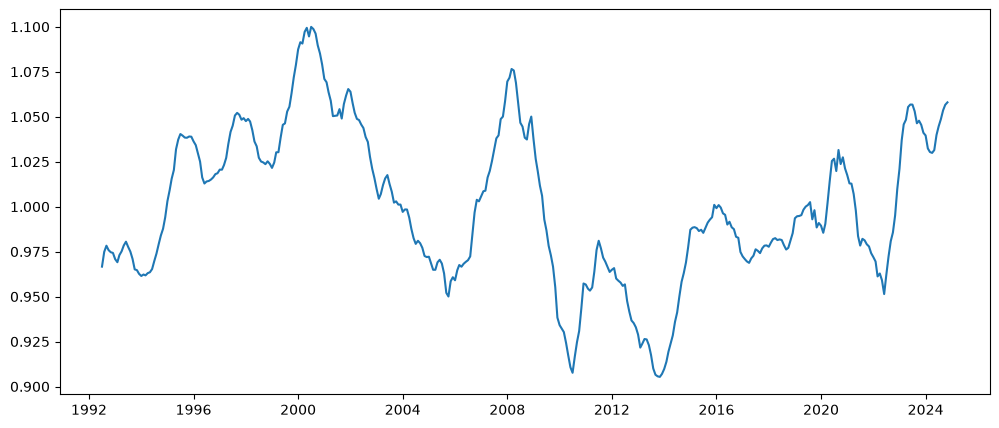

In [14]:
for exp in [0.6]:
    series = df['Y_infl_adj'] / df['US All home sales'].rolling(window=12, min_periods=1, center=True).mean().shift(6)**exp
    plt.plot(series/series.mean())
    print(series.var()/series.mean()**2)

0.006537095963715733 0 0.0006686303569327544
0.005812519572037381 250 0.0006234858092368726
0.00515715952653854 500 0.0005783412615409907
0.004370751151004105 1000 0.0004880521661492271
0.004546069163536897 1250 0.0004429076184533453
0.005504584455187814 1500 0.0003977630707574635


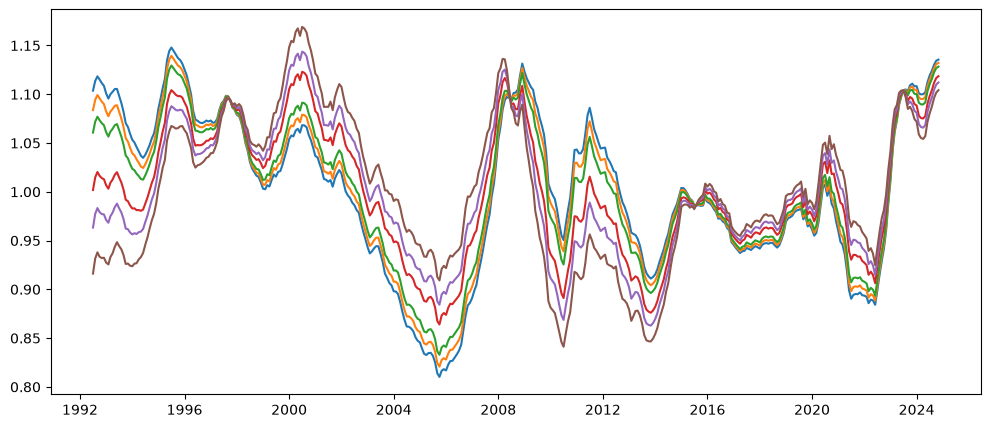

In [15]:
for other_sales in [0,250,500,1000,1250,1500]:
    series = (df['Y_infl_adj'] - other_sales) / df['US All home sales'].rolling(window=12, min_periods=1, center=True).mean().shift(6)
    plt.plot(series/series.mean())
    print(series.var()/series.mean()**2, other_sales, series.mean())

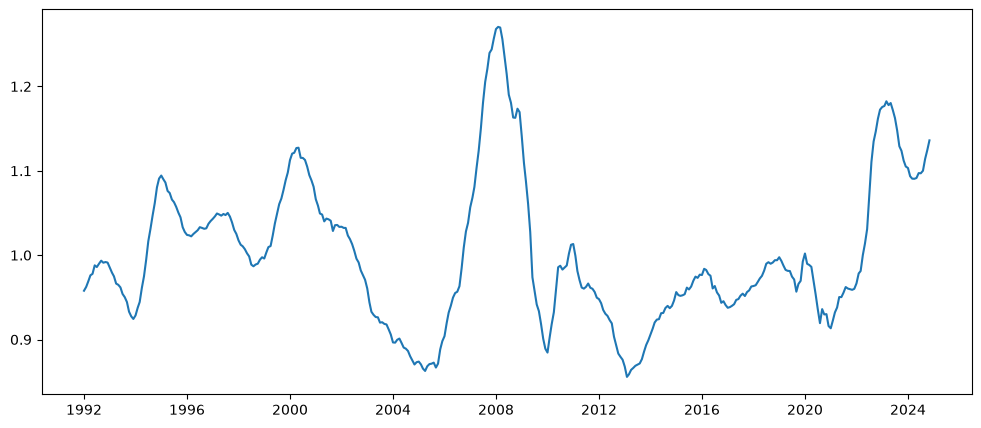

In [16]:
other_sales = 1000
series = (df['Y_infl_adj'] - other_sales) / df['US All home sales'].rolling(window=12, min_periods=1, center=True).mean() 
plt.plot(series/series.mean())

#### VAR model

In [17]:
df['roll US All home sales'] = df['US All home sales'].rolling(window=12, min_periods=1, center=True).mean()
df['9-shift roll US All home sales'] = df['roll US All home sales'].shift(9)

VAR_model_cols = [
    'Y_infl_adj', 
    'roll US All home sales', 
    # 'Households', 
    # 'CB CCI', 
    # 'Real Personal Consumption Expenditures per household', 
    # 'PCE'
]

data = df[VAR_model_cols].ffill()
data = data / data.max()

VAR_model = VAR(data, dates=data.index)
VAR_results = VAR_model.fit(maxlags=12, ic='aic')  # Automatically select optimal lag using AIC

# Summary of the model
print(VAR_results.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 19, Sep, 2026
Time:                     16:39:40
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -22.9648
Nobs:                     393.000    HQIC:                  -23.2701
Log likelihood:           3546.65    FPE:                6.41329e-11
AIC:                     -23.4704    Det(Omega_mle):     5.66909e-11
--------------------------------------------------------------------
Results for equation Y_infl_adj
                                coefficient       std. error           t-stat            prob
---------------------------------------------------------------------------------------------
const                              0.004932         0.001701            2.900           0.004
L1.Y_infl_adj                      1.327295         0.051644           25.701           0.000
L1.

C:\Users\illoi\AppData\Local\Temp\ipykernel_44248\493138260.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['roll US All home sales'] = df['US All home sales'].rolling(window=12, min_periods=1, center=True).mean()
C:\Users\illoi\AppData\Local\Temp\ipykernel_44248\493138260.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['9-shift roll US All home sales'] = df['roll US All home sales'].shift(9)
C:\Users\illoi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313

<BarContainer object of 12 artists>

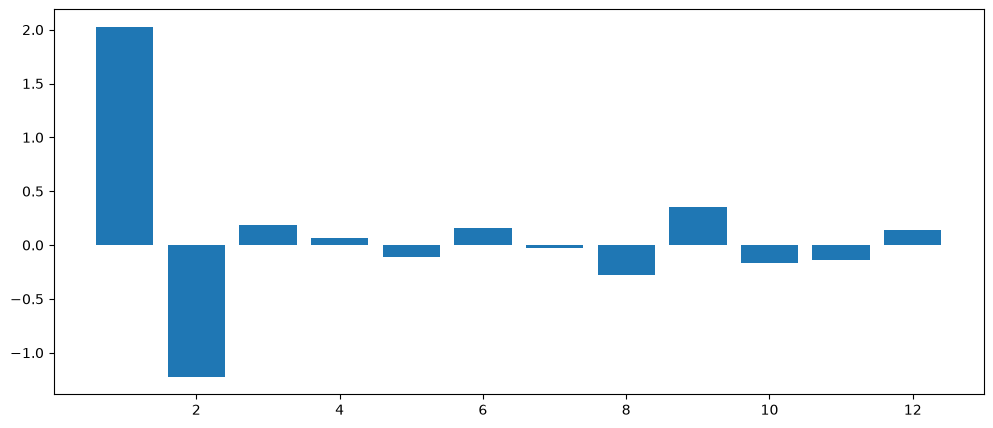

In [18]:
plt.bar(range(1,len(VAR_results.coefs[:,1,1])+1), VAR_results.coefs[:,1,1])

In [19]:
# Forecasting example (next 5 steps)
lag_order = VAR_results.k_ar
forecast_input = data.values[-lag_order:]
forecast = VAR_results.forecast(y=forecast_input, steps=5)
forecast_df = pd.DataFrame(forecast, columns=VAR_model_cols)

print(lag_order)
print(forecast_df)

12
   Y_infl_adj  roll US All home sales
0    0.776185                0.548460
1    0.776037                0.550885
2    0.775904                0.553471
3    0.775682                0.556622
4    0.775458                0.559979


#### Modelling with Machine Learning

##### Quick modelling

In [20]:
model_cols = [
    'Real Disposable Personal Income Per Capita',
    'Real Household Debt Service',
    'Real Personal Consumption Expenditures per household',
    'PCE',
    'FEDFUNDS',
    'roll_pct_chg_M2SL',
    'HF Affordability index'
]

In [21]:
m2_df = pd.DataFrame([])
m2_df['Y'] = df['Y_infl_adj'].ffill()
# m_df['Y'] = df['Y'] / (df['HF Affordability index'].ffill() / df['HF Affordability index'].iloc[0]) ** 0.4
m2_df['HS'] = df['US All home sales'].shift(8).bfill()
m2_df['HH'] = forward_fill_increment(df['Households'], df['Households'].diff().mean())
m2_df[model_cols] = df[model_cols].ffill()

m2_df.head()

,Y,HS,HH,Real Disposable Personal Income Per Capita,Real Household Debt Service,Real Personal Consumption Expenditures per household,PCE,FEDFUNDS,roll_pct_chg_M2SL,HF Affordability index
1992-01-01,2874.625555,3936000.0,95669000.0,29487.0,3519.311864,75.674101,4084.7,4.03,0.000724,1.000000
1992-02-01,2880.907287,3936000.0,95669000.0,29487.0,3533.070337,75.783899,4099.5,4.06,0.000628,1.015776
1992-03-01,2890.224002,3936000.0,95669000.0,29487.0,3529.998079,75.833836,4117.0,3.98,0.000744,1.031703
1992-04-01,2906.447274,3936000.0,95669000.0,29487.0,3485.153152,75.937146,4131.5,3.73,0.001074,1.038827
1992-05-01,2919.560675,3936000.0,95669000.0,29487.0,3496.050597,76.267435,4158.4,3.82,0.001395,1.016254


In [22]:
y = df['Y']

m2_df = m2_df.dropna()
X2 = m2_df.drop(columns=['Y'])
y2 = m2_df['Y']

In [23]:
scaler = MinMaxScaler()
X2_scaled = scaler.fit_transform(X2)

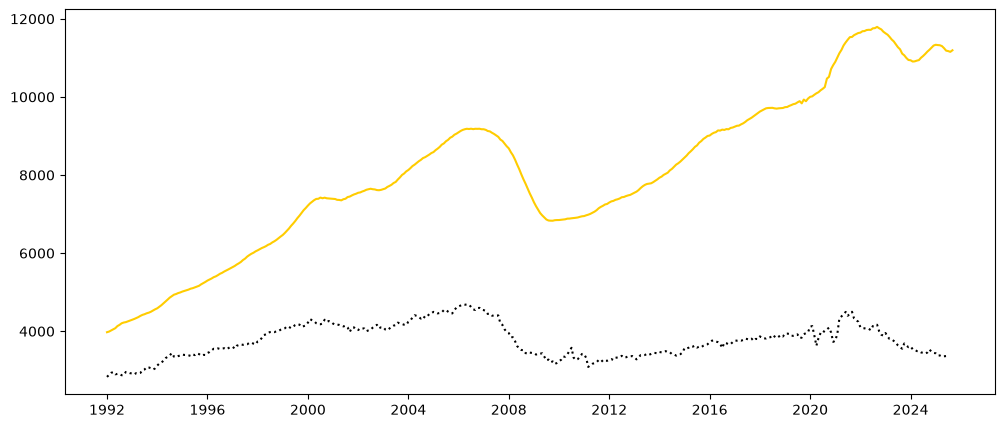

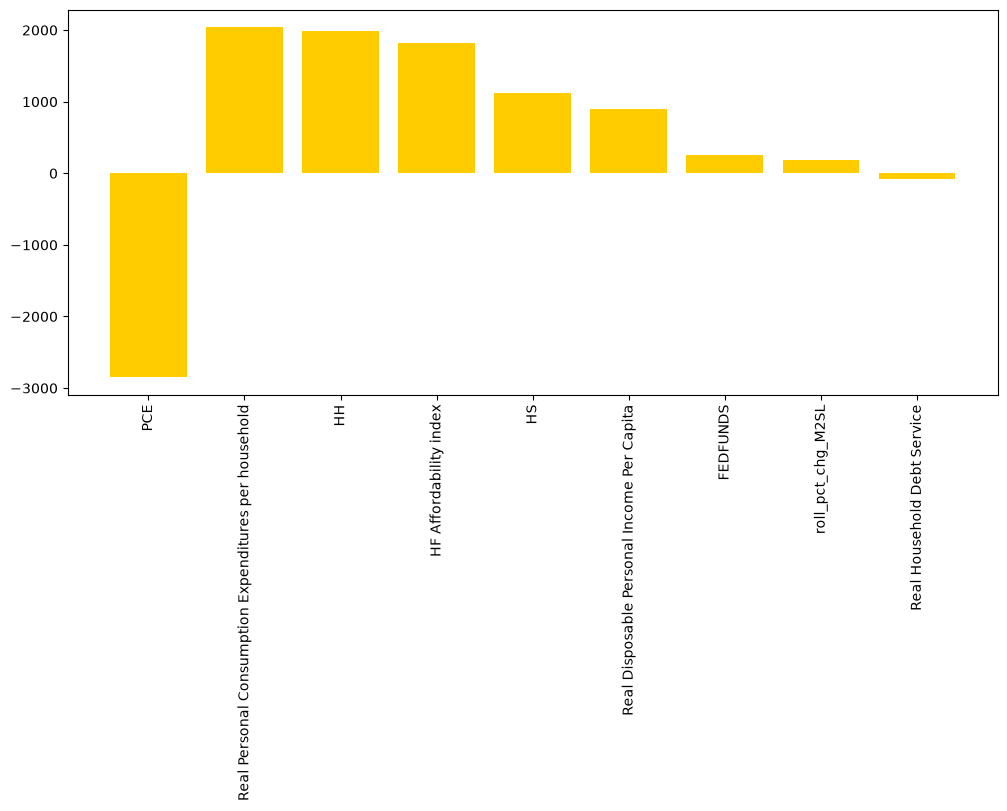

In [24]:
lin_reg2 = LinearRegression()
lin_reg2.fit(X2_scaled, y2)

y_lin_model_arr2 = lin_reg2.predict(X2_scaled)
y_lin_model_series2 = pd.Series(y_lin_model_arr2, index=m2_df.index)

LR_coeffs2 = pd.Series(lin_reg2.coef_, index=X2.columns).sort_values(key=abs, ascending=False)

plt.figure()
plt.plot(y, color=color3)
plt.plot(y_lin_model_series2, color=color1, linestyle=':')

plt.figure()
plt.bar(x=LR_coeffs2.index, height=LR_coeffs2, color=color3)
plt.xticks(rotation=90);


--- Random Forest Evaluation ---
MAPE:       0.0129
Adjusted R²:0.9749
BIC:        3474.93
RMSE:       70.4515


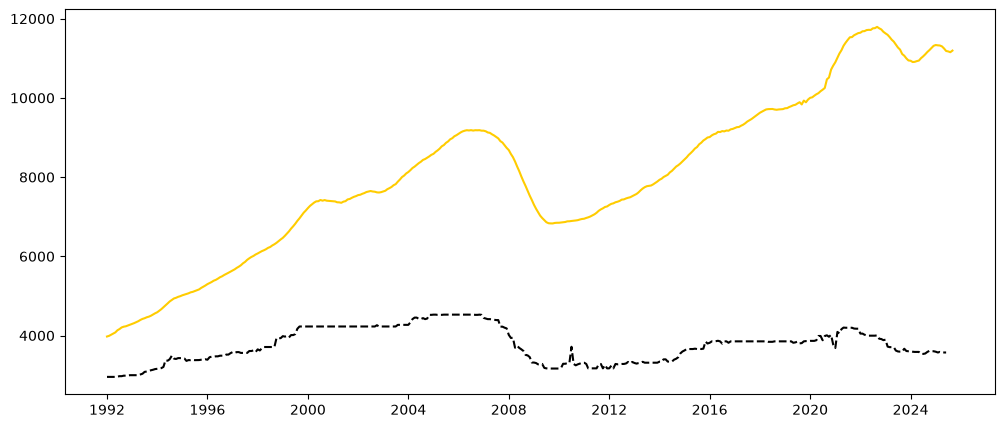

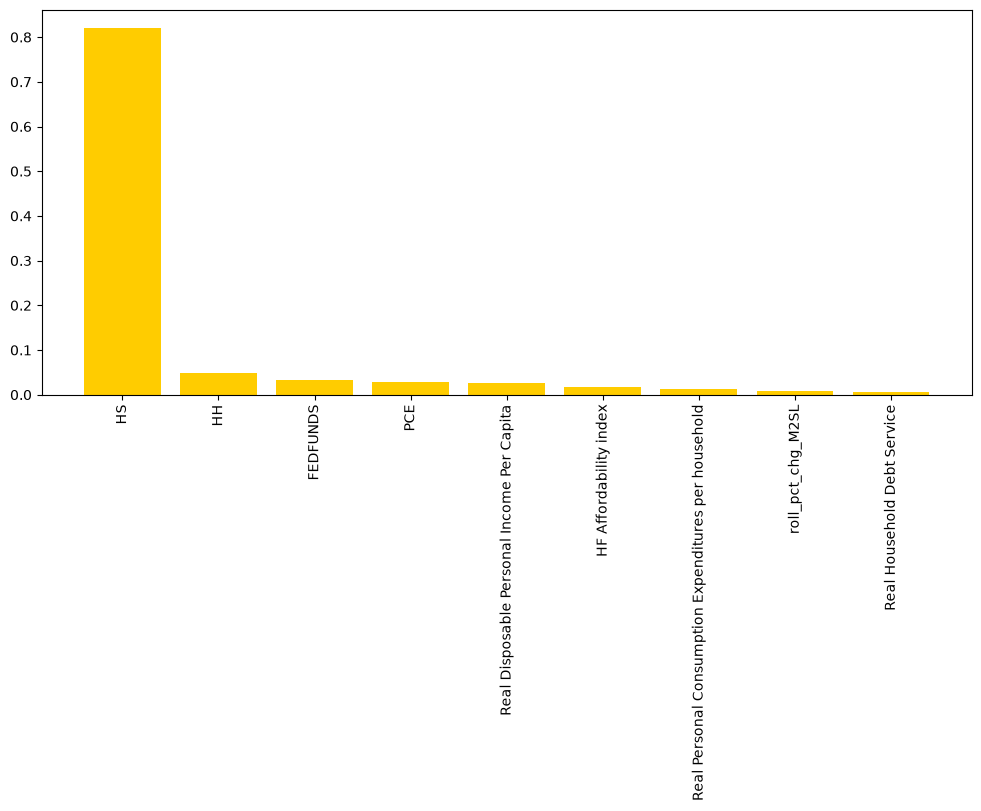

In [25]:
rf2 = RandomForestRegressor(n_estimators=20, max_depth=4, min_samples_leaf=3, random_state=42)
rf2.fit(X2, y2)

y_rf_arr2 = rf2.predict(X2)
y_rf_series2 = pd.Series(y_rf_arr2, index=m2_df.index)

rf_importance2 = pd.Series(rf2.feature_importances_, index=X2.columns).sort_values(ascending=False)

plt.figure()
plt.plot(y, color=color3)
plt.plot(y_rf_series2, color=color1, linestyle='--')

plt.figure()
plt.bar(x=rf_importance2.index, height=rf_importance2, color=color3)
plt.xticks(rotation=90)

evaluate_model("Random Forest", rf2, X2, y2)

##### Trying out something more complex

In [26]:
m_df = pd.DataFrame([])
m_df['Y'] = df['Y_infl_adj'].ffill()
# m_df['Y'] = df['Y'] / (df['HF Affordability index'].ffill() / df['HF Affordability index'].iloc[0]) ** 0.4
m_df['HS'] = df['US All home sales'].shift(8).bfill()
m_df['HH'] = forward_fill_increment(df['Households'], df['Households'].diff().mean())

for col in model_cols:
    m_df['HS x ' + col] = m_df['HS'] * df[col].ffill()
    m_df['HH x ' + col] = m_df['HH'] * df[col].ffill()

m_df.head()

,Y,HS,HH,HS x Real Disposable Personal Income Per Capita,HH x Real Disposable Personal Income Per Capita,HS x Real Household Debt Service,HH x Real Household Debt Service,HS x Real Personal Consumption Expenditures per household,HH x Real Personal Consumption Expenditures per household,HS x PCE,HH x PCE,HS x FEDFUNDS,HH x FEDFUNDS,HS x roll_pct_chg_M2SL,HH x roll_pct_chg_M2SL,HS x HF Affordability index,HH x HF Affordability index
1992-01-01,2874.625555,3936000.0,95669000.0,1.160608e+11,2.820992e+12,1.385201e+10,3.366890e+11,2.978533e+08,7.239666e+09,1.607738e+10,3.907792e+11,15862080.0,385546070.0,2849.456535,69259.313327,3.936000e+06,9.566900e+07
1992-02-01,2880.907287,3936000.0,95669000.0,1.160608e+11,2.820992e+12,1.390616e+10,3.380053e+11,2.982854e+08,7.250170e+09,1.613563e+10,3.921951e+11,15980160.0,388416140.0,2471.205331,60065.483449,3.998094e+06,9.717828e+07
1992-03-01,2890.224002,3936000.0,95669000.0,1.160608e+11,2.820992e+12,1.389407e+10,3.377114e+11,2.984820e+08,7.254947e+09,1.620451e+10,3.938693e+11,15665280.0,380762620.0,2929.985421,71216.660381,4.060784e+06,9.870202e+07
1992-04-01,2906.447274,3936000.0,95669000.0,1.160608e+11,2.820992e+12,1.371756e+10,3.334211e+11,2.988886e+08,7.264831e+09,1.626158e+10,3.952565e+11,14681280.0,356845370.0,4228.442434,102777.149182,4.088821e+06,9.938349e+07
1992-05-01,2919.560675,3936000.0,95669000.0,1.160608e+11,2.820992e+12,1.376046e+10,3.344637e+11,3.001886e+08,7.296429e+09,1.636746e+10,3.978300e+11,15035520.0,365455580.0,5489.841488,133436.901767,3.999974e+06,9.722397e+07


In [27]:
exit_path = "C:/Users/illoi/Escritorio-2/00 - RETAIL INSIGHTS & ANALYTICS/01 - MARKET ANALYSIS/Data/US - Copy"
file_name = 'm_df.csv'
sep = ','

m_df.to_csv(os.path.join(exit_path, file_name), sep=sep)

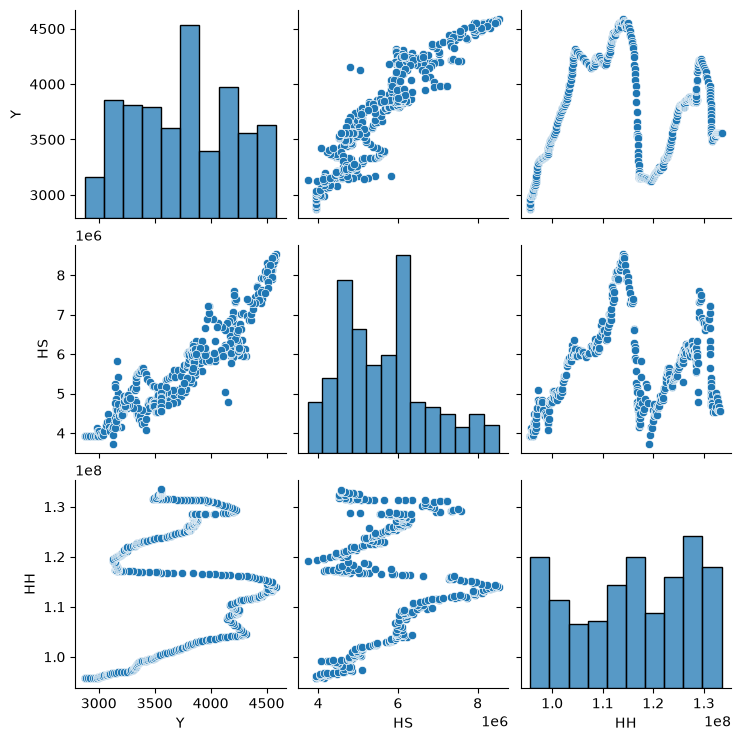

In [28]:
sns.pairplot(m_df.iloc[:,:3])

In [29]:
m_df = m_df.dropna()
X = m_df.drop(columns=['Y', 'HS', 'HH'])
y = m_df['Y']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

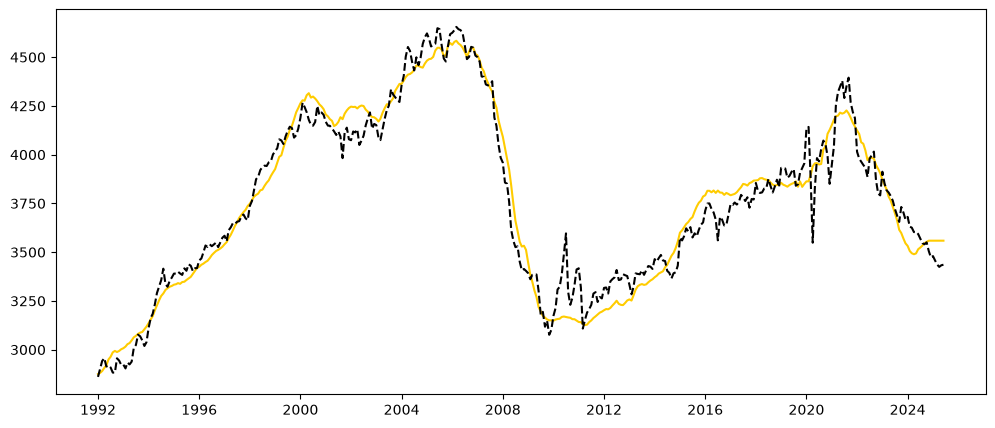

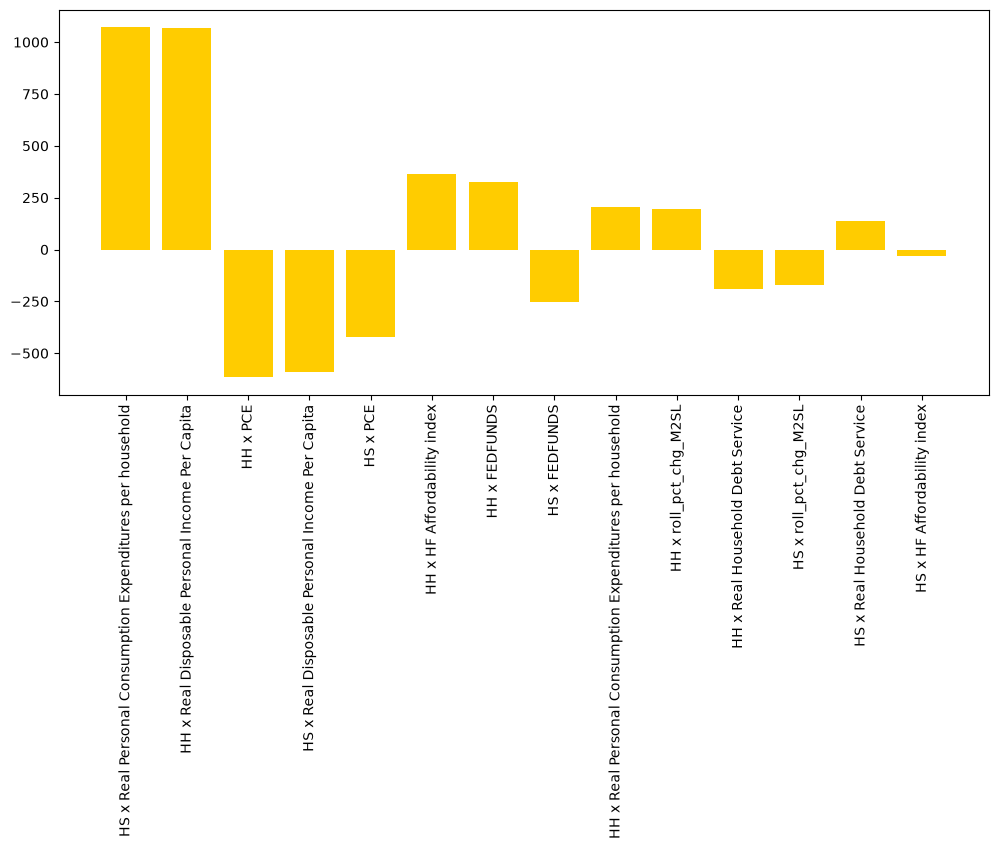

In [30]:
lin_reg = LinearRegression()
lin_reg.fit(X_scaled, y)

y_lin_model_arr = lin_reg.predict(X_scaled)
y_lin_model_series = pd.Series(y_lin_model_arr, index=m_df.index)

LR_coeffs = pd.Series(lin_reg.coef_, index=X.columns).sort_values(key=abs, ascending=False)

plt.figure()
plt.plot(y, color=color3)
plt.plot(y_lin_model_series, color=color1, linestyle='--')

plt.figure()
plt.bar(x=LR_coeffs.index, height=LR_coeffs, color=color3)
plt.xticks(rotation=90);

In [31]:
rfe = RFE(estimator=lin_reg, n_features_to_select=5)
rfe.fit(X_scaled, y)
selected_rfe = X.columns[rfe.support_]
print("\n[RFE] Selected Features:")
for feat in selected_rfe:
    print(feat)


[RFE] Selected Features:
HS x Real Disposable Personal Income Per Capita
HH x Real Disposable Personal Income Per Capita
HS x Real Personal Consumption Expenditures per household
HS x PCE
HH x HF Affordability index


In [32]:
# lasso = LassoCV(cv=3).fit(X_scaled, y)
# model_lasso = SelectFromModel(lasso, prefit=True)
# selected_lasso = X.columns[model_lasso.get_support()]
# print("\n[Lasso] Selected Features:")
# for feat in selected_lasso:
#     print(feat)

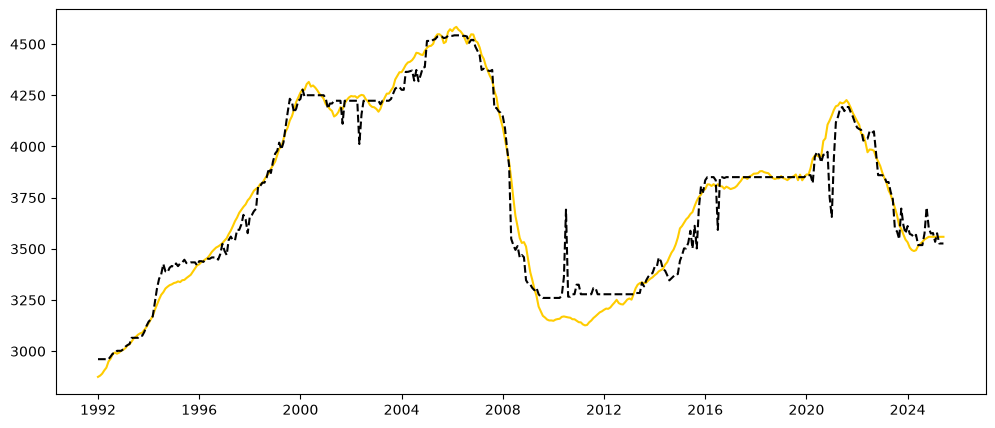

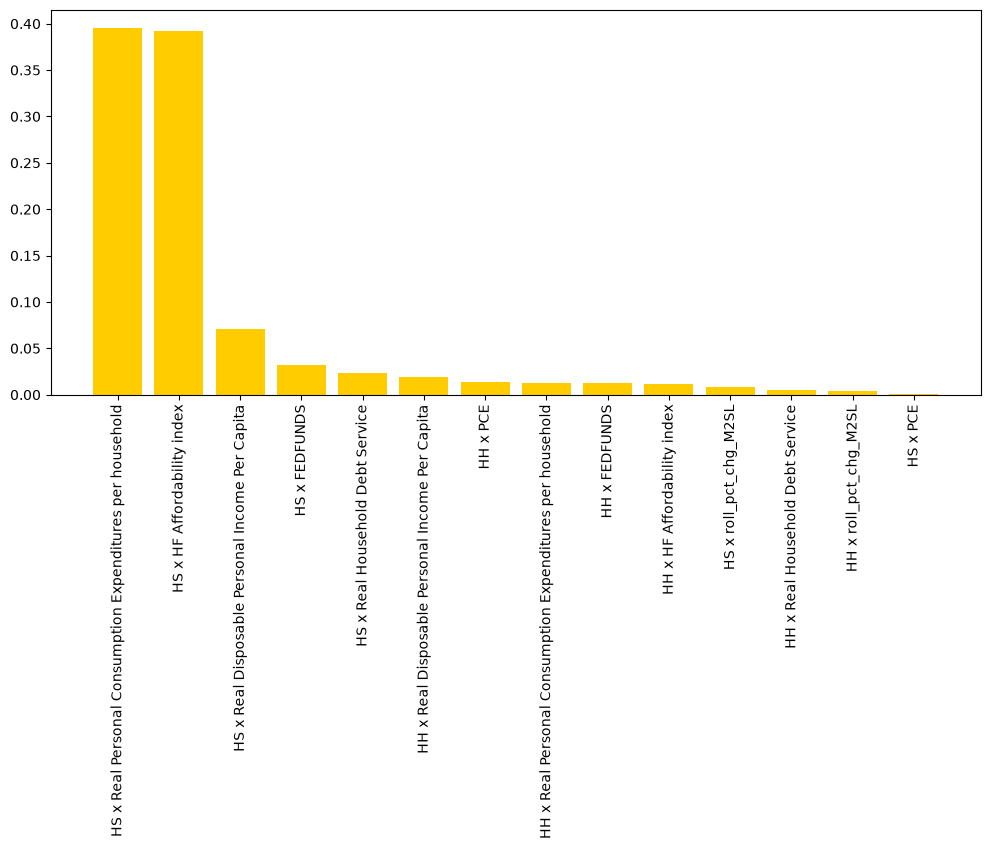

In [33]:
rf = RandomForestRegressor(n_estimators=20, max_depth=4, min_samples_leaf=3, random_state=42)
rf.fit(X, y)

y_rf_arr = rf.predict(X)
y_rf_series = pd.Series(y_rf_arr, index=m_df.index)

rf_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure()
plt.plot(y, color=color3)
plt.plot(y_rf_series, color=color1, linestyle='--')

plt.figure()
plt.bar(x=rf_importance.index, height=rf_importance, color=color3)
plt.xticks(rotation=90);

In [34]:
# Evaluate both models
evaluate_model("Linear Regression", lin_reg, X_scaled, y)
evaluate_model("Random Forest", rf, X, y)


--- Linear Regression Evaluation ---
MAPE:       0.0210
Adjusted R²:0.9517
BIC:        3763.40
RMSE:       97.1675

--- Random Forest Evaluation ---
MAPE:       0.0150
Adjusted R²:0.9667
BIC:        3613.80
RMSE:       80.6697


#### All variables

In [35]:
model_cols = [
    # 'Real Disposable Personal Income Per Capita',
    # 'Real Household Debt Service',
    # 'Real Personal Consumption Expenditures per household',
    # 'PCE',
    # 'FEDFUNDS',
    # 'roll_pct_chg_M2SL',
    # 'Households',
    'HF Affordability index',
    'Y',
    'Y_infl_adj'
]

m3_df = df[model_cols].copy()

m3_df['Y_infl_adj'] = m3_df['Y_infl_adj'].ffill()
m3_df['Home sales'] = df['US All home sales'].shift(8).bfill()
m3_df['Households'] = forward_fill_increment(df['Households'], df['Households'].diff().mean())

In [36]:
m3_df['Y_adj'] = m3_df['Y'] / m3_df['HF Affordability index'].rolling(window=12, min_periods=1, center=True).mean()
m3_df['Y_infl_adj_adj'] = m3_df['Y_infl_adj'] / m3_df['HF Affordability index'].rolling(window=12, min_periods=1, center=True).mean()

<Axes: >

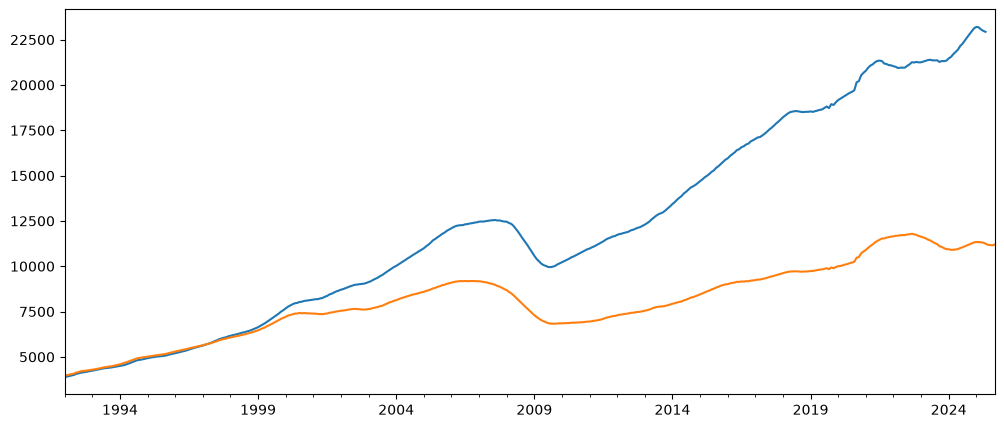

In [37]:
m3_df['Y_adj'].plot()
m3_df['Y'].plot()

In [38]:
m3_df = m3_df.dropna()
X3 = m3_df.drop(columns=['Y', 'Y_adj', 'Y_infl_adj', 'Y_infl_adj_adj', 'HF Affordability index'])
y3 = m3_df['Y_infl_adj_adj']

scaler = MinMaxScaler()
X3_scaled = scaler.fit_transform(X3)

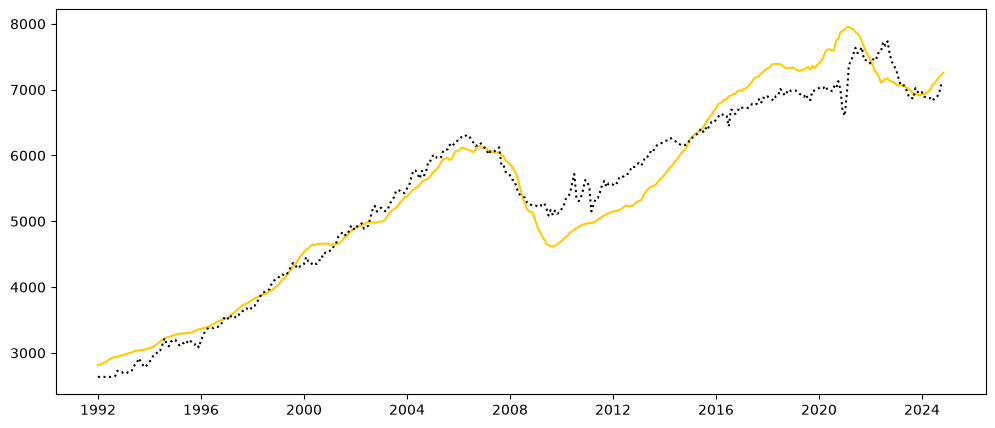

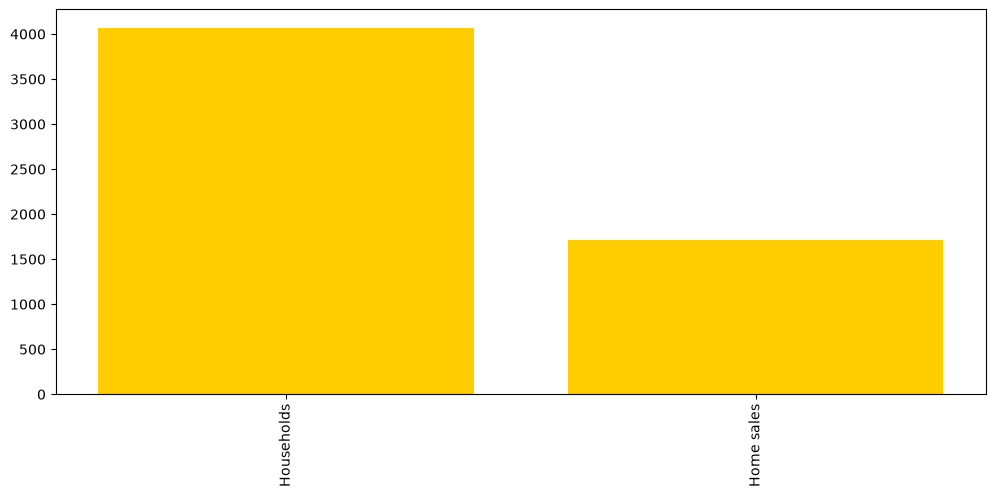

In [39]:
lin_reg3 = LinearRegression()
lin_reg3.fit(X3_scaled, y3)

y_lin_model_arr3 = lin_reg3.predict(X3_scaled)
y_lin_model_series3 = pd.Series(y_lin_model_arr3, index=m3_df.index)

LR_coeffs3 = pd.Series(lin_reg3.coef_, index=X3.columns).sort_values(key=abs, ascending=False)

plt.figure()
plt.plot(y3, color=color3)
plt.plot(y_lin_model_series3, color=color1, linestyle=':')

plt.figure()
plt.bar(x=LR_coeffs3.index, height=LR_coeffs3, color=color3)
plt.xticks(rotation=90);

In [40]:
evaluate_model("Linear Regression", lin_reg3, X3_scaled, y3)


--- Linear Regression Evaluation ---
MAPE:       0.0456
Adjusted R²:0.9520
BIC:        4558.02
RMSE:       315.6096


#### Trying out other models

##### Corrected excess analysis and model

11
-0.18187263967031037


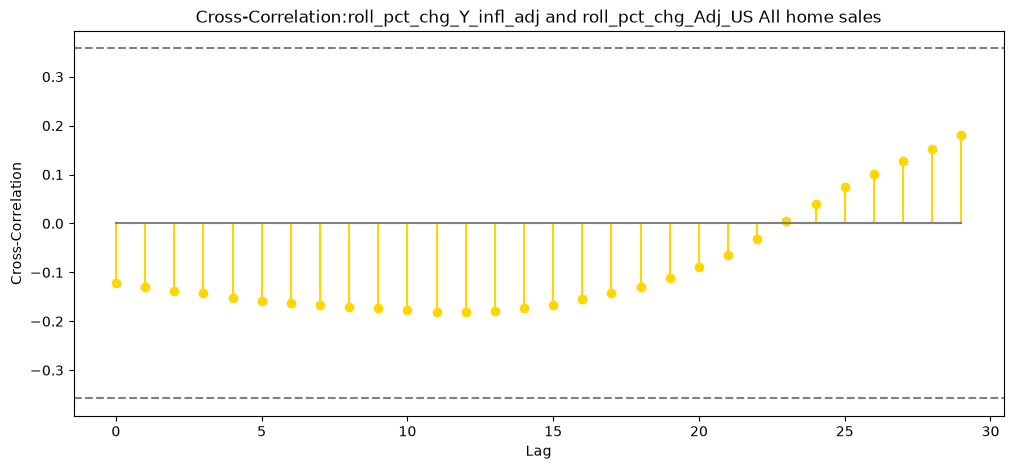

In [41]:
IR_MORT_ccf = ccf_funct(df['roll_pct_chg_Y_infl_adj'].dropna(), df['roll_pct_chg_Adj_US All home sales'].dropna(), 30)

PearsonRResult(statistic=np.float64(-0.18765225550008793), pvalue=np.float64(0.00021308362640547462))

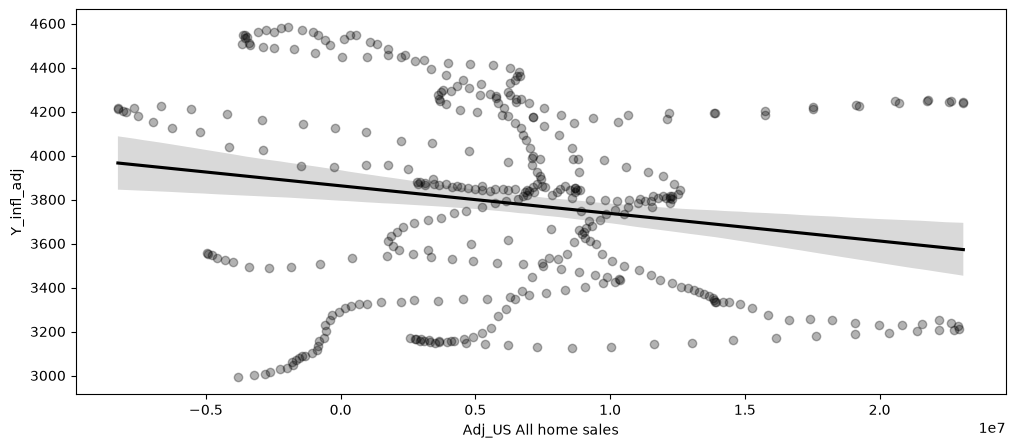

In [42]:
shift = -7
var1='Adj_US All home sales'
var2='Y_infl_adj'

scatter_kws={'alpha':0.3, 'color':'black'}
line_kws={'color':'black'}

houses_sold_roll_series = df[var1].rolling(window=12, min_periods=1, center=True).mean()
IA_shifted_series = df[var2].shift(shift)

join_index = df[(~houses_sold_roll_series.isna()) & (~IA_shifted_series.isna())].index

houses_sold_roll_series = houses_sold_roll_series[join_index]
IA_shifted_series = IA_shifted_series[join_index]

sns.regplot(x=houses_sold_roll_series, y=IA_shifted_series, scatter_kws=scatter_kws, line_kws=line_kws)
pearsonr(houses_sold_roll_series, IA_shifted_series)

-150.5119130734426
3862.2710769998366


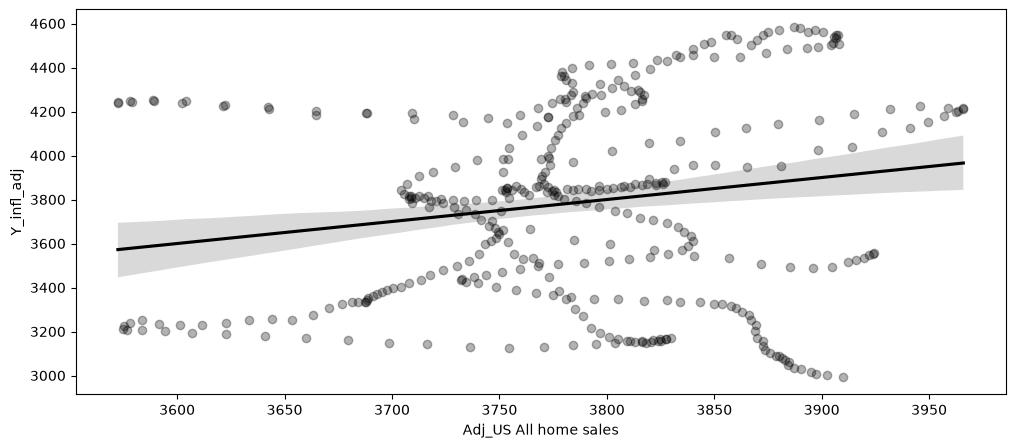

In [43]:
x = houses_sold_roll_series
y = IA_shifted_series

IA_coefs = np.polyfit(x, y , deg = 1)
y_hat = IA_coefs[0] * x + IA_coefs[1]

sns.regplot(x=y_hat, y=y, scatter_kws=scatter_kws, line_kws=line_kws)
print(f * IA_coefs[0])
print(IA_coefs[1])

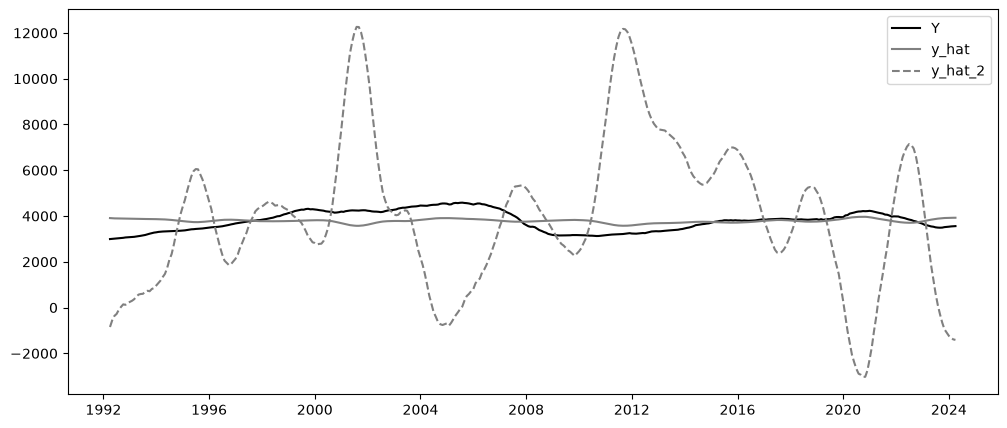

In [44]:
y_hat_2 = series.mean() * x + other_sales

# plt.plot(df['Y_infl_adj'], label='Y_infl_adj')
plt.plot(y, color='black', label='Y')
plt.plot(y_hat, color='grey', label='y_hat')
plt.plot(y_hat_2, color='grey', linestyle='--', label='y_hat_2')
plt.legend();

##### GR 2 model

[ 2.03333413e-13 -1.55580914e-05  3.86437857e+03]
29.280011447308254
-186.69709678293606
3864.3785675933946


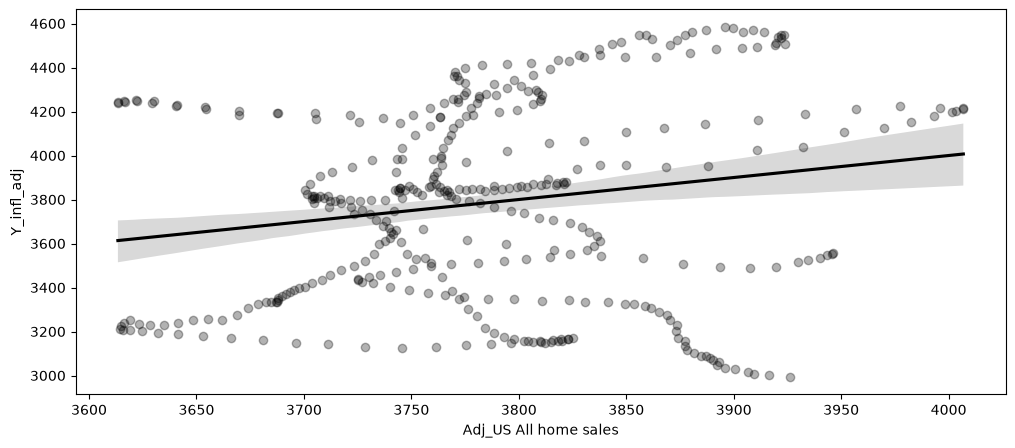

In [45]:
x = houses_sold_roll_series
y = IA_shifted_series

IA_coefs_gr2 = np.polyfit(x, y , deg = 2)
print(IA_coefs_gr2)
y_hat_gr2 = IA_coefs_gr2[0] * x**2 + IA_coefs_gr2[1] * x + IA_coefs_gr2[2]

sns.regplot(x=y_hat_gr2, y=y, scatter_kws=scatter_kws, line_kws=line_kws)
print(f**2 * IA_coefs_gr2[0])
print(f * IA_coefs_gr2[1])
print(IA_coefs_gr2[2])

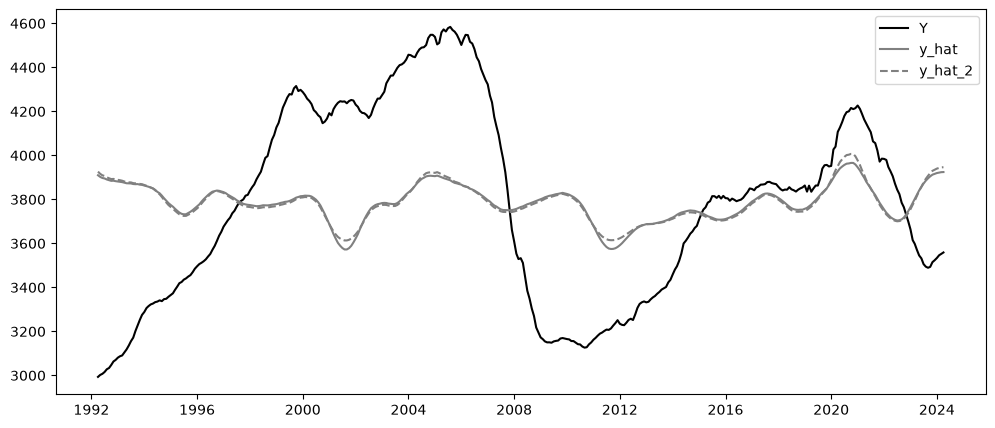

In [46]:
plt.plot(y, color='black', label='Y')
plt.plot(y_hat, color='grey', label='y_hat')
plt.plot(y_hat_gr2, color='grey', linestyle='--', label='y_hat_2')
plt.legend();

9.890211935317135 %: average error


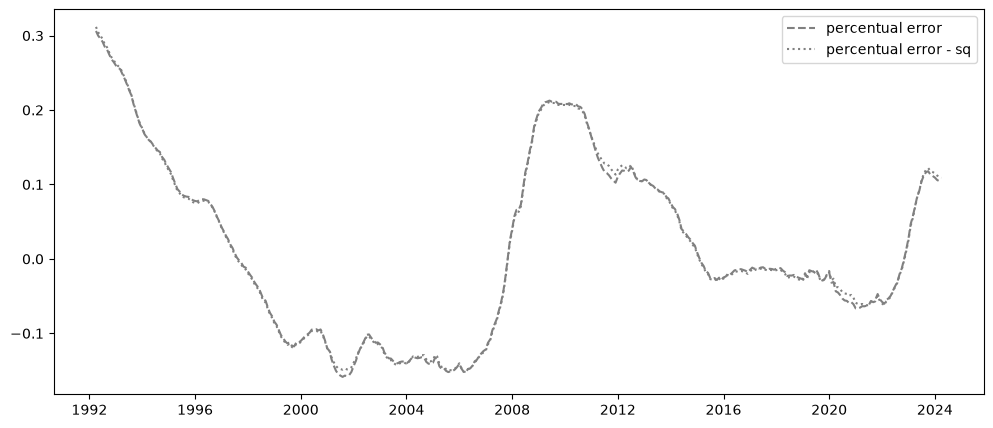

In [47]:
plt.plot((y_hat - y)/y, color='grey', linestyle='--', label='percentual error')
plt.plot((y_hat_gr2 - y)/y, color='grey', linestyle=':', label='percentual error - sq')
plt.legend()
print((abs((y_hat_gr2 - y)/y)).mean() * 100, '%: average error')

#### Correlate

np.int64(12)

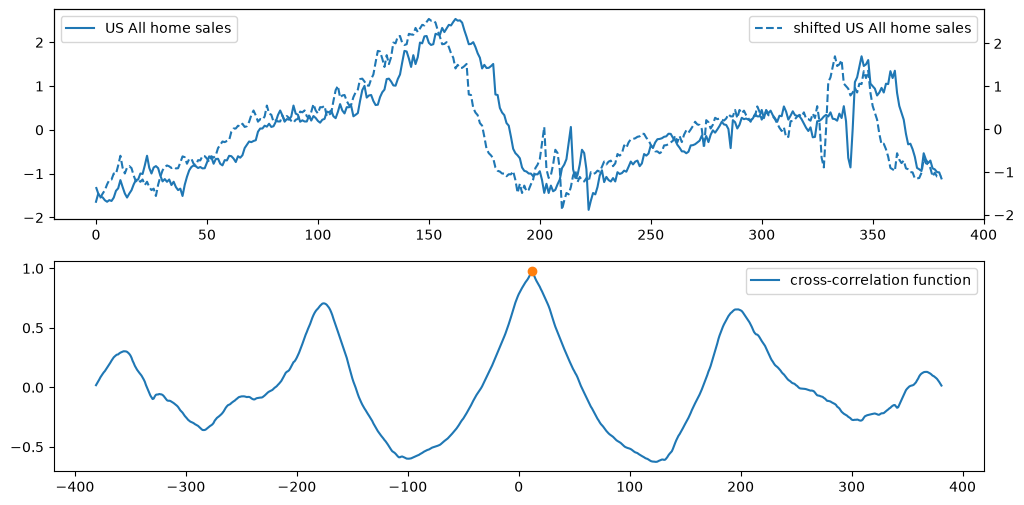

In [48]:
col1_ = 'US All home sales'
shift = - 12

aux_df = pd.DataFrame(df[col1_])
col2_ = 'shifted ' + col1_
aux_df[col2_] = aux_df[col1_].shift(shift)

aux_df = aux_df[[col1_, col2_]].dropna().copy()

cross_correlate(aux_df, col1_, col2_)

np.int64(7)

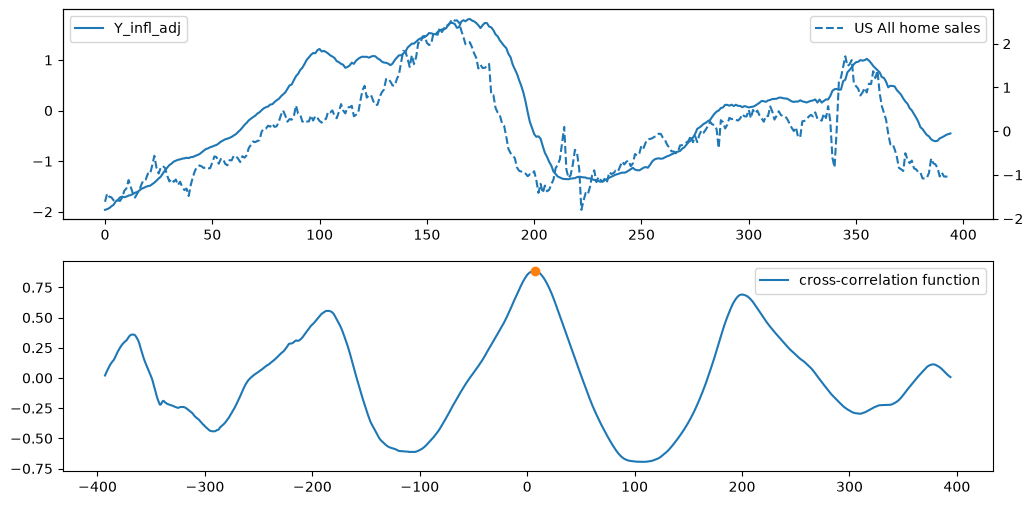

In [49]:
cross_correlate(df, 'Y_infl_adj', 'US All home sales')

np.int64(-165)

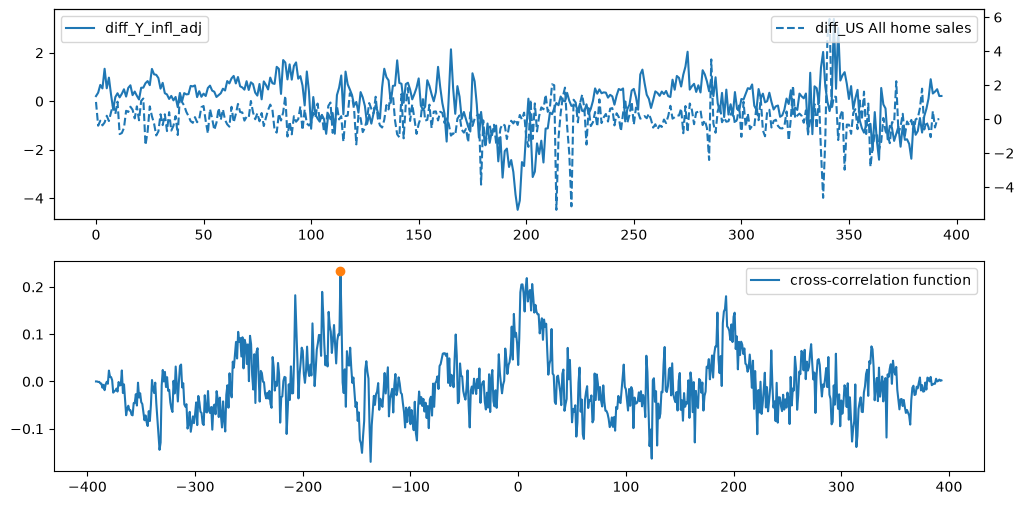

In [50]:
cross_correlate(df, 'diff_Y_infl_adj', 'diff_US All home sales')

np.int64(9)

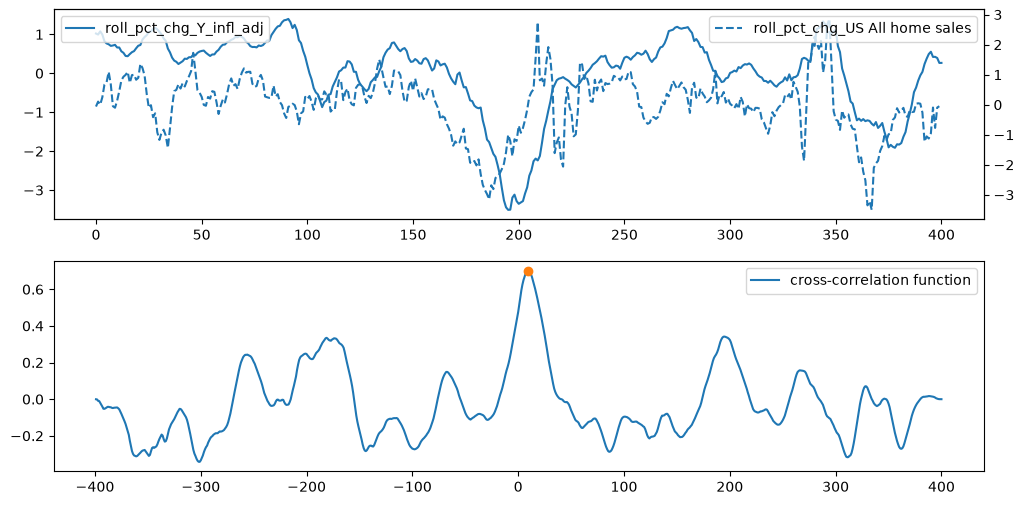

In [51]:
cross_correlate(df, 'roll_pct_chg_Y_infl_adj', 'roll_pct_chg_US All home sales')

np.int64(-294)

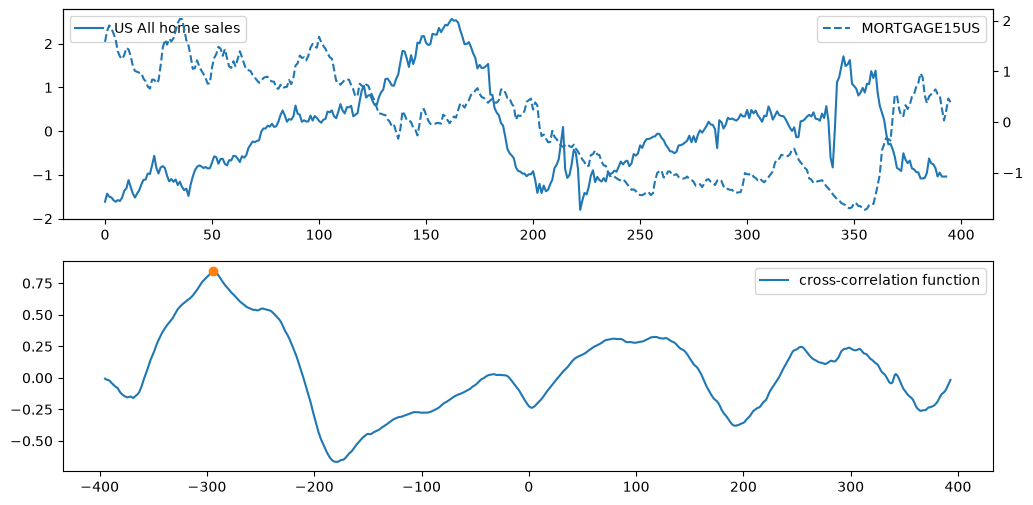

In [52]:
cross_correlate(df, 'US All home sales', 'MORTGAGE15US')

np.int64(-1)

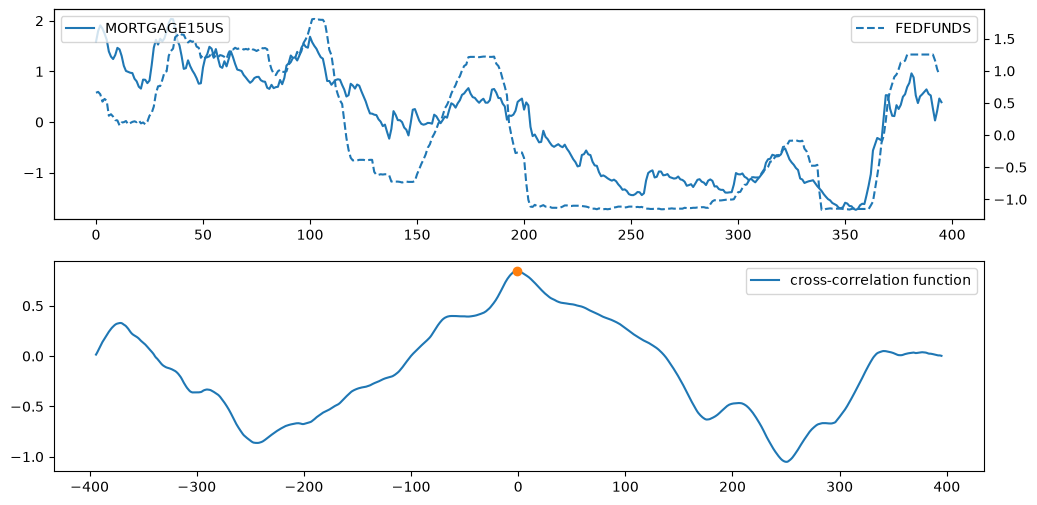

In [53]:
cross_correlate(df, 'MORTGAGE15US', 'FEDFUNDS')

np.int64(-2)

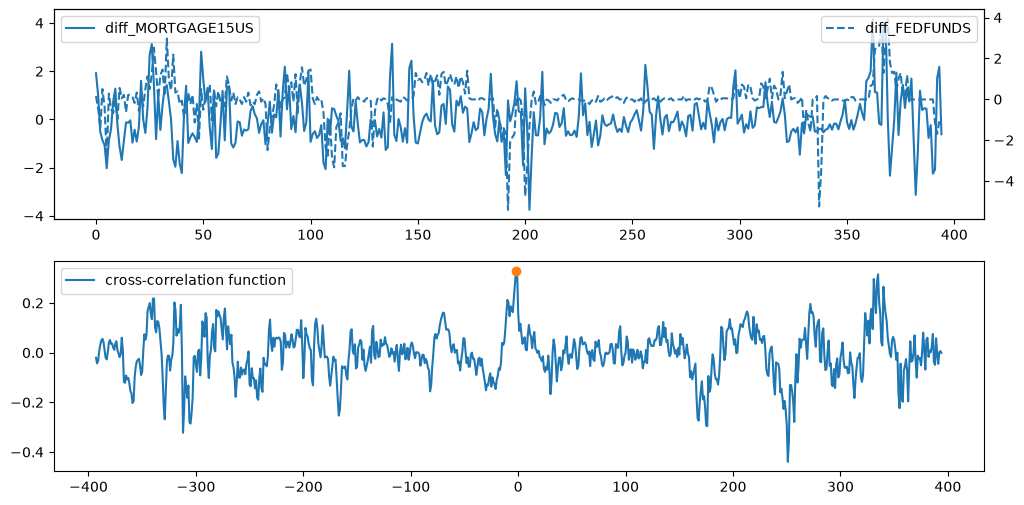

In [54]:
cross_correlate(df, 'diff_MORTGAGE15US', 'diff_FEDFUNDS')

#### Variable lag

(np.int64(13), np.float64(0.40896037812948455))

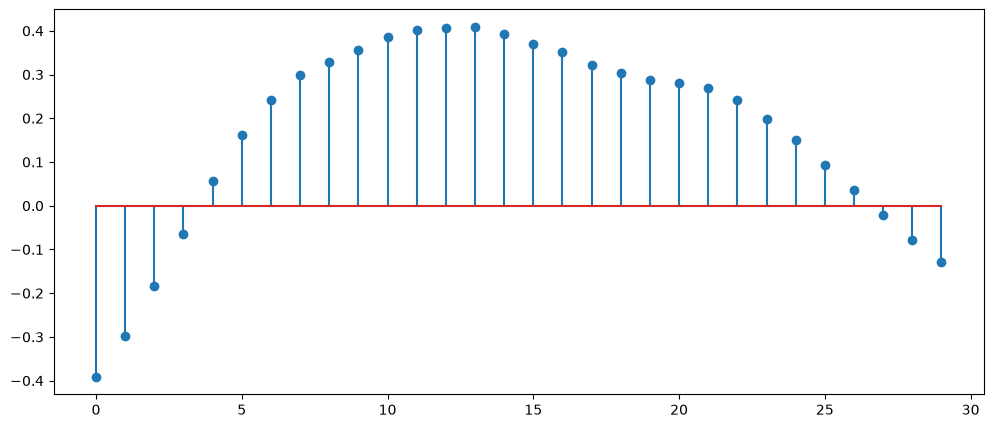

In [55]:
limit = 30
size = 96
a = 0
col1 = 'roll_pct_chg_Y_infl_adj'
col2 = 'roll_pct_chg_US All home sales'
interval=(a,a + size)

plot_ccf_2(df, col1, col2, limit, interval)

(np.int64(10), np.float64(0.9087578461660571))

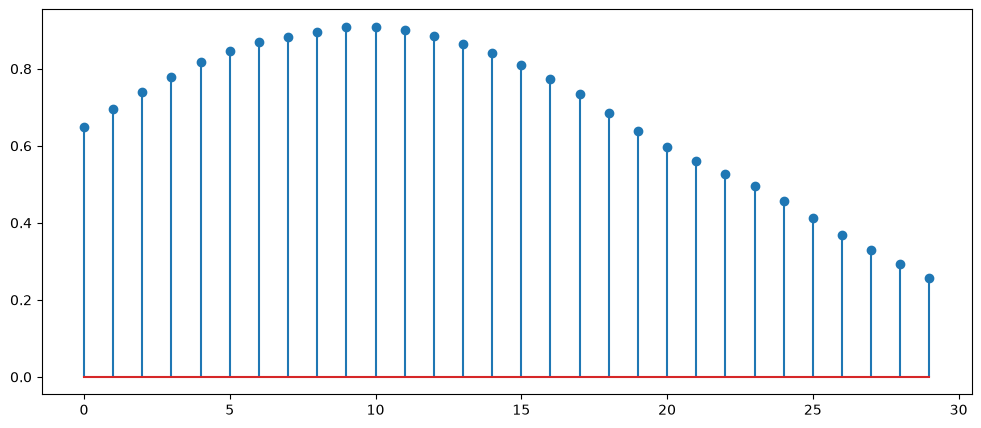

In [56]:
a = 108
interval=(a,a + size)

plot_ccf_2(df, col1, col2, limit, interval)

(np.int64(10), np.float64(0.7282534126905991))

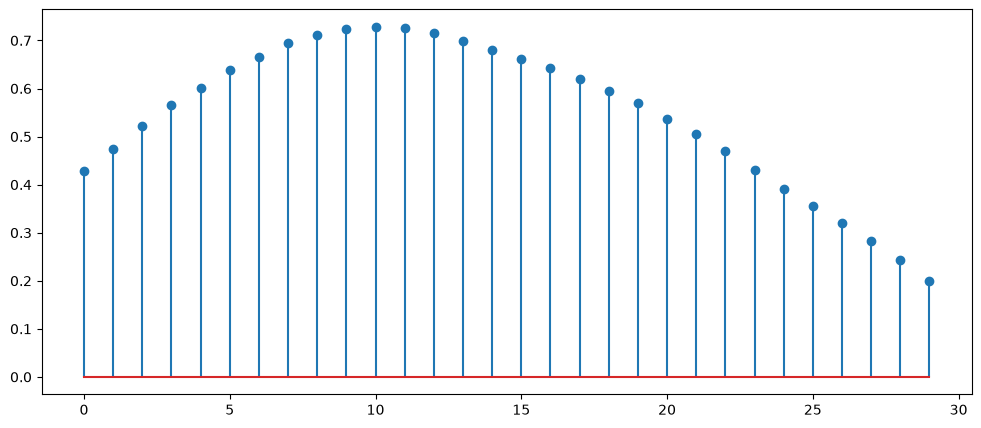

In [57]:
a = 180
interval=(a,a + size)

plot_ccf_2(df, col1, col2, limit, interval)

(np.int64(4), np.float64(0.7133442702697892))

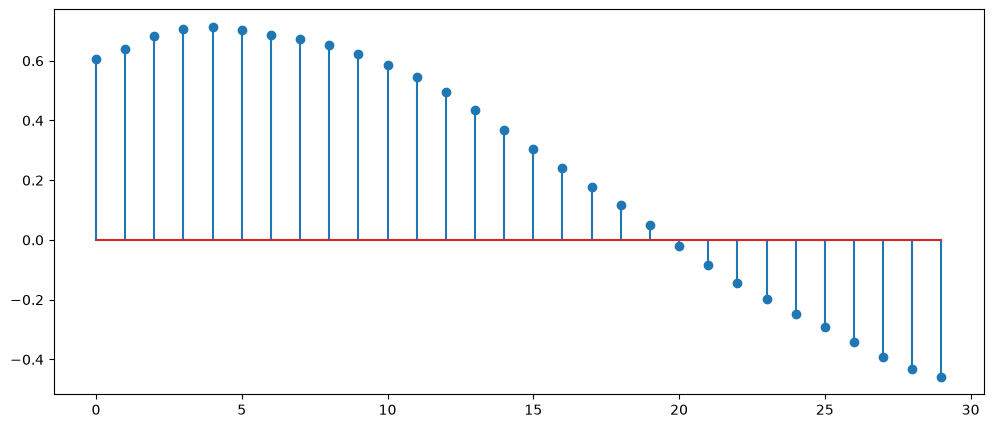

In [58]:
a = - size - 1
interval=(a,a + size)

plot_ccf_2(df, col1, col2, limit, interval)

In [59]:
# [x for x in df.columns if 'US All' in x]

<StemContainer object of 3 artists>

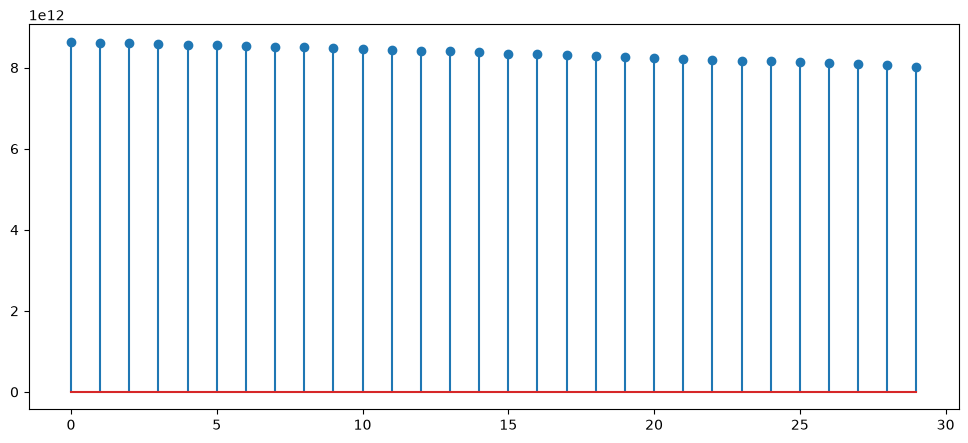

In [60]:
nlags = 30
ccf_vals_list = list()

col1 = 'Y_infl_adj'
col2 = 'US All home sales'

for n in [int(n) for n in np.linspace(0, -nlags-1, nlags)]:
    aux_df = df[[col1, col2]].dropna().copy()
    shifted_col2 = 'shifted_' + col2
    aux_df[shifted_col2] = df[col2].shift(n)
    aux_df = aux_df.dropna()
    ccf_vals_list.append(np.correlate(aux_df[col1], aux_df[shifted_col2]))

plt.stem(ccf_vals_list)

<Axes: >

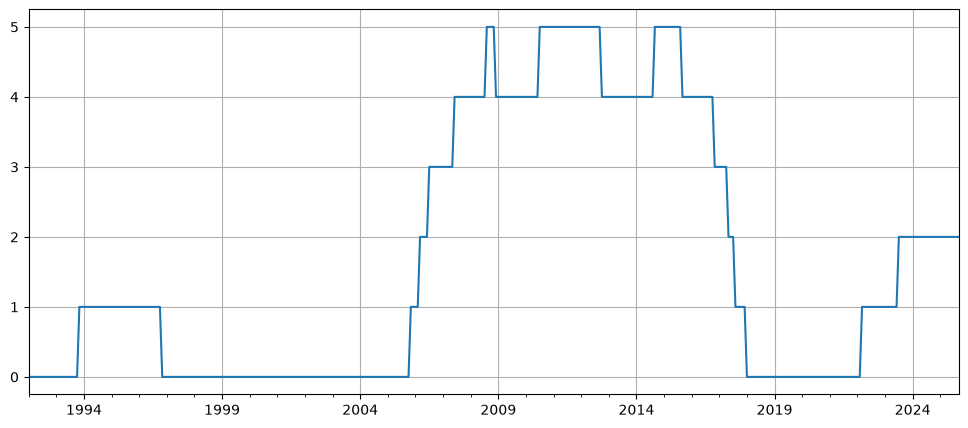

In [61]:
col1 = 'Y_infl_adj'
col2 = 'roll US All home sales'

lags_series = df[col1].rolling(window=96, min_periods=1).apply(roll_apply_max_ccf, args=(df,col1,col2,30), raw=False)
lags_series = lags_series.rolling(window=36, min_periods=1, center=True).mean().round()
lags_series.plot(grid=True)

In [62]:
col3 = 'Y_infl_adj'
col4 = 'US All home sales'

ndf = df.reset_index()
ndf.index.name = 'prov_index'

# lags_series = np.concatenate((np.zeros(156), np.full(84, 10), np.full(len(df) - 240, 4)))

df['Y_houses_lag'] = lags_series

for col in [col3, col4]:
    lagged_index = np.array(df.reset_index().index) + np.array(lags_series)
    lagged_series = pd.Series(np.array(df[col]), index = lagged_index)
    lagged_series = lagged_series.groupby(lagged_series.index).mean()
    custom_lag_col_name = 'custom_shifted_' + col
    lagged_series.name = custom_lag_col_name
    lagged_series.index.name = 'prov_index'
    
    ndf = ndf.merge(lagged_series, how='left', on='prov_index')
    ndf[custom_lag_col_name] = ndf[custom_lag_col_name].bfill()

ndf.set_index('index', inplace=True)

C:\Users\illoi\AppData\Local\Temp\ipykernel_44248\1102771895.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ndf = df.reset_index()
C:\Users\illoi\AppData\Local\Temp\ipykernel_44248\1102771895.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Y_houses_lag'] = lags_series
C:\Users\illoi\AppData\Local\Temp\ipykernel_44248\1102771895.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once 

PearsonRResult(statistic=np.float64(0.9750182787794891), pvalue=np.float64(3.0329943178084796e-258))

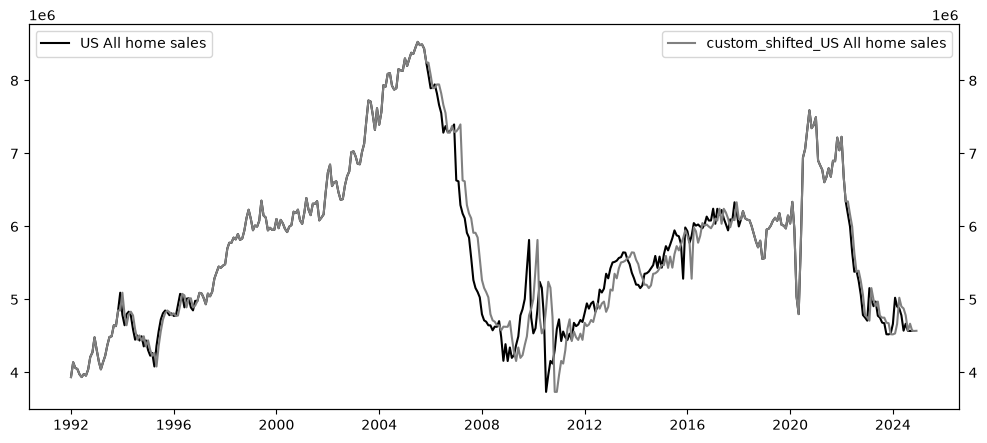

In [63]:
dual_plot_corr(ndf[col4], ndf[custom_lag_col_name])

PearsonRResult(statistic=np.float64(0.8549749158873078), pvalue=np.float64(8.124015313980239e-114))

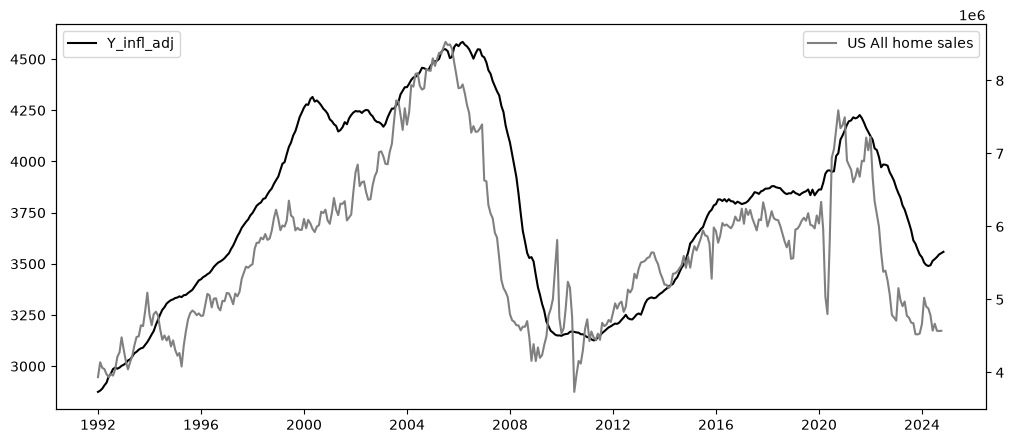

In [64]:
dual_plot_corr(ndf['Y_infl_adj'], ndf['US All home sales'])

6
0.9101608563772594


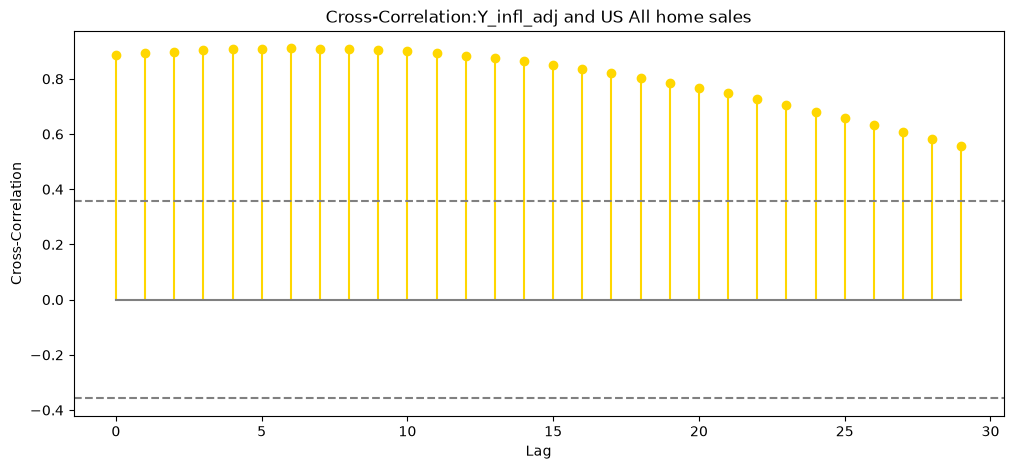

In [65]:
ccf_funct(df['Y_infl_adj'].dropna(), df['US All home sales'].rolling(window=12, min_periods=1, center=True).mean().dropna(), 30);

4324.601447237832
1701.7974879956164


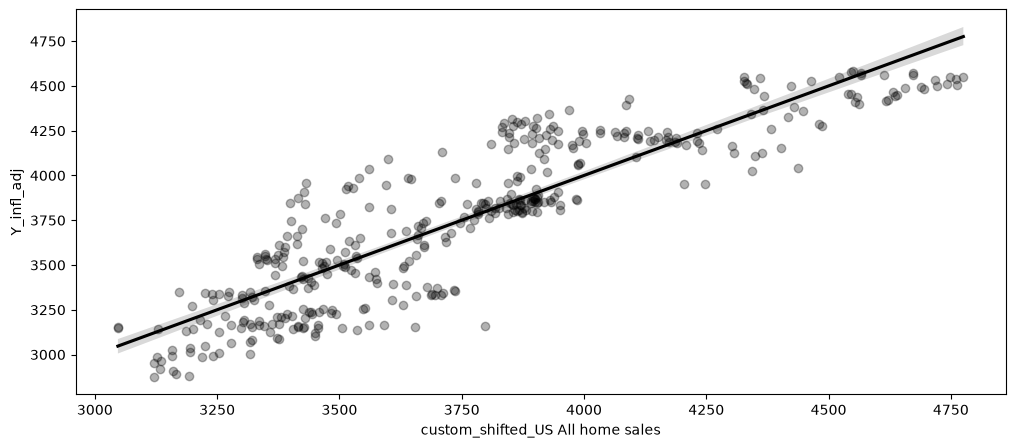

In [66]:
var1=custom_lag_col_name
var2='Y_infl_adj'

aux_df = ndf[[var1, var2]].dropna()

x = aux_df[var1]
y = aux_df[var2]

IA_coefs = np.polyfit(x, y , deg = 1)
y_hat = IA_coefs[0] * x + IA_coefs[1]

sns.regplot(x=y_hat, y=y, scatter_kws=scatter_kws, line_kws=line_kws)
print(f * IA_coefs[0])
print(IA_coefs[1])

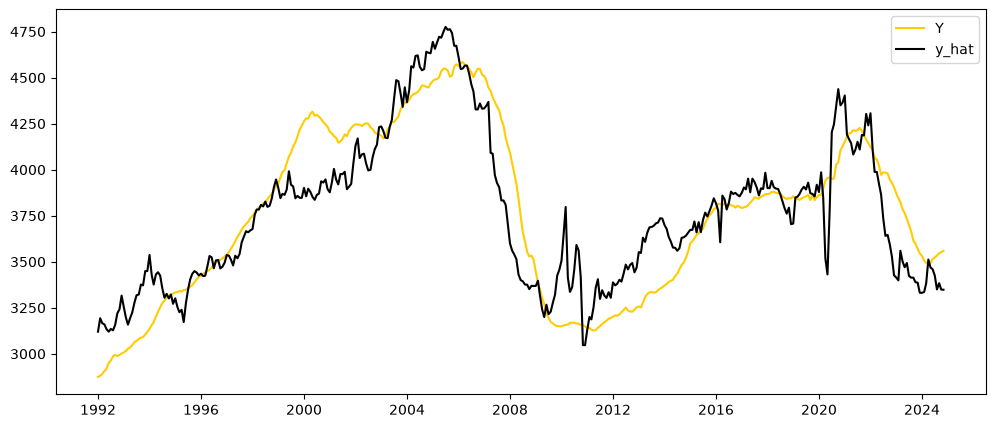

In [67]:
plt.plot(y, color=color3, label='Y')
plt.plot(y_hat, color=color1, label='y_hat')
plt.legend();

4.4442110666701815 %: average error


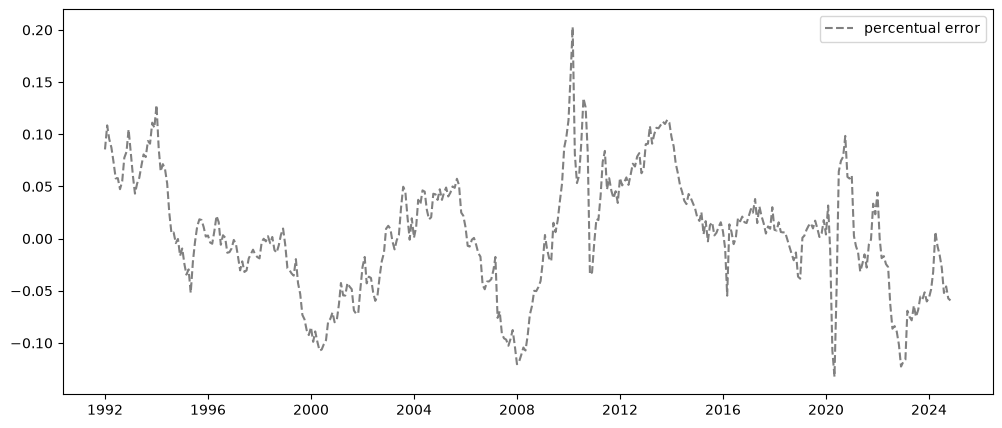

In [68]:
plt.plot((y_hat - y)/y, color='grey', linestyle='--', label='percentual error')
plt.legend()
print((abs((y_hat - y)/y)).mean() * 100, '%: average error')

#### Other models 2

##### Intro

In [69]:
df['6M_shift_roll_US All home sales'] = df['US All home sales'].rolling(window=12, min_periods=1, center=True).mean().shift(6)
df['12M_shift_roll_US All home sales'] = df['US All home sales'].rolling(window=12, min_periods=1, center=True).mean().shift(12)

C:\Users\illoi\AppData\Local\Temp\ipykernel_44248\1345106802.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['6M_shift_roll_US All home sales'] = df['US All home sales'].rolling(window=12, min_periods=1, center=True).mean().shift(6)
C:\Users\illoi\AppData\Local\Temp\ipykernel_44248\1345106802.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['12M_shift_roll_US All home sales'] = df['US All home sales'].rolling(window=12, min_periods=1, center=True).mean().shift(12)


C:\Users\illoi\AppData\Local\Temp\ipykernel_44248\4285899203.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Y_infl_adj_min_RE_HS'] = df['Y_infl_adj'] - IA_coefs[0] * df['6M_shift_roll_US All home sales']


<Axes: >

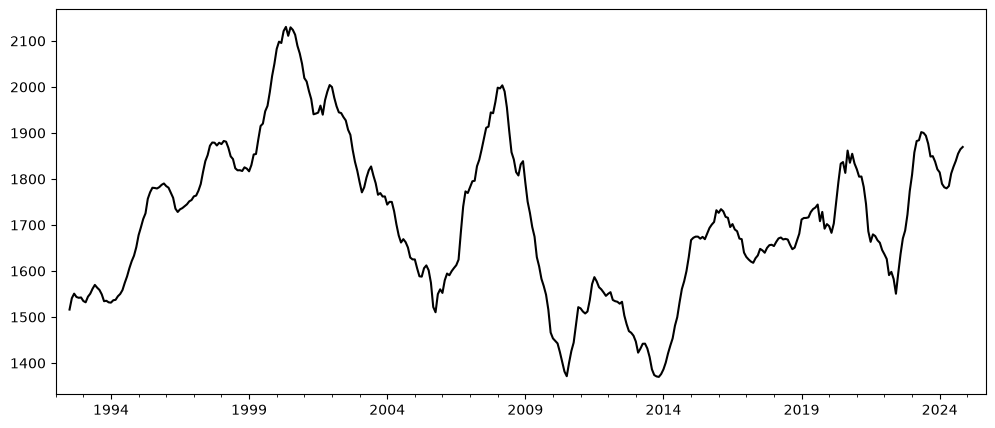

In [70]:
# plt.plot(df['Y_infl_adj'])
df['Y_infl_adj_min_RE_HS'] = df['Y_infl_adj'] - IA_coefs[0] * df['6M_shift_roll_US All home sales']
df['Y_infl_adj_min_RE_HS'].plot(color='black')

PearsonRResult(statistic=np.float64(-0.19342063915961383), pvalue=np.float64(0.00013400977921944636))

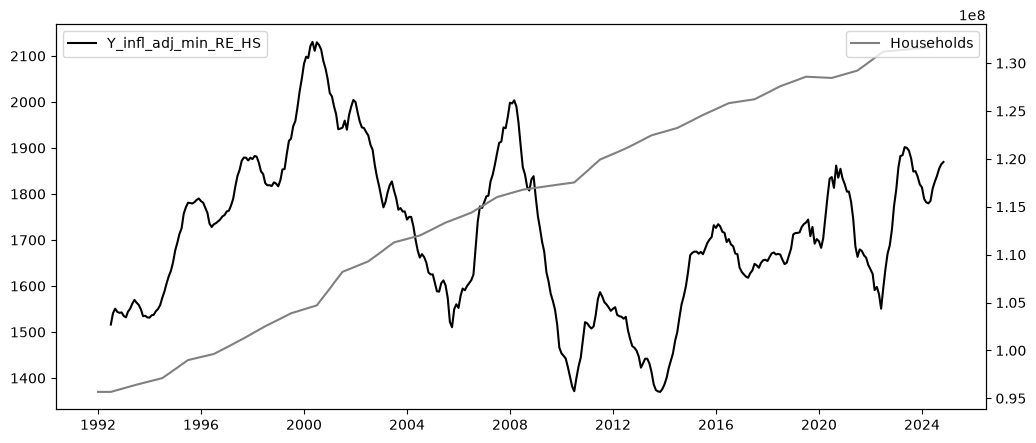

In [71]:
dual_plot_corr(df['Y_infl_adj_min_RE_HS'], df['Households'])

C:\Users\illoi\AppData\Local\Temp\ipykernel_44248\3561094059.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['roll_pct_chg_Y_infl_adj_min_RE_HS'] = df['Y_infl_adj_min_RE_HS'].pct_change(fill_method=None).rolling(window=12, min_periods=1, center=True).mean()


PearsonRResult(statistic=np.float64(0.06821059043318603), pvalue=np.float64(0.17607527013541535))

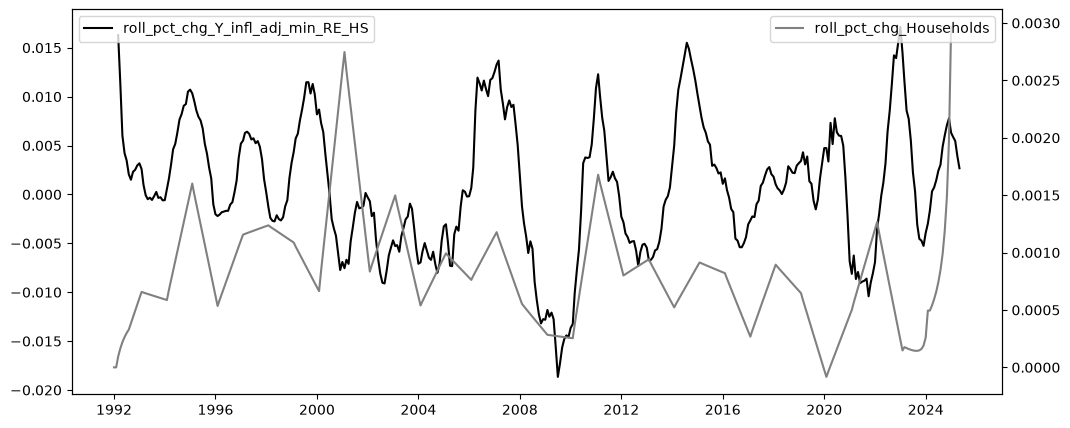

In [72]:
df['roll_pct_chg_Y_infl_adj_min_RE_HS'] = df['Y_infl_adj_min_RE_HS'].pct_change(fill_method=None).rolling(window=12, min_periods=1, center=True).mean()
dual_plot_corr(df['roll_pct_chg_Y_infl_adj_min_RE_HS'], df['roll_pct_chg_Households'])

PearsonRResult(statistic=np.float64(-0.0261297735239662), pvalue=np.float64(0.6027895753110222))

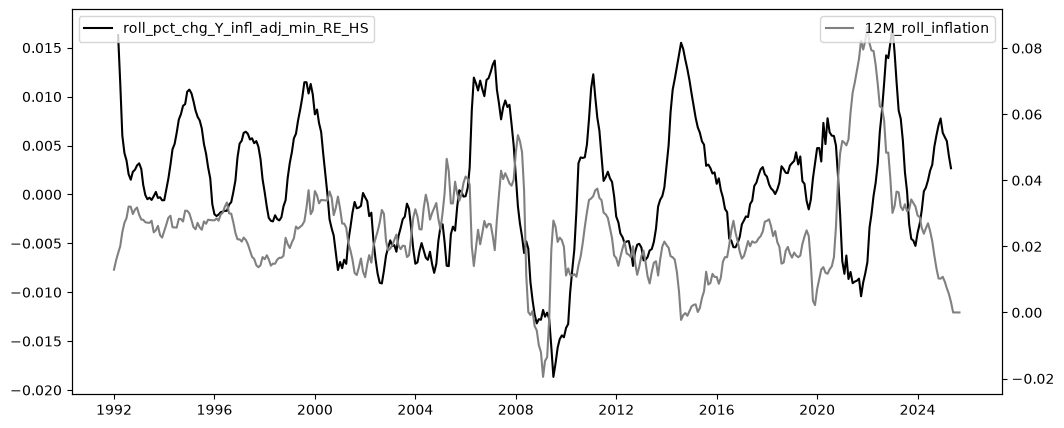

In [73]:
dual_plot_corr(df['roll_pct_chg_Y_infl_adj_min_RE_HS'], df['12M_roll_inflation'])

##### Model - Home sales + households

In [74]:
x_cols = ['Households', '6M_shift_roll_US All home sales', '12M_shift_roll_US All home sales', 'roll US All home sales']
# x_cols = ['shift_roll_Real Estate - market sales']
aux_df = df[x_cols + ['Y_infl_adj']].dropna()

X = aux_df[x_cols]
y = aux_df['Y_infl_adj']

fitted_lin_model = LinearRegression().fit(X, y)

In [75]:
fitted_lin_model.coef_

array([-5.70429411e-06, -1.90044634e-04,  3.78128985e-04,  2.37544161e-04])

In [76]:
fitted_lin_model.coef_[1] * f

np.float64(-2280.5356112073673)

In [77]:
print(df['Y'].mean())
print(df['Y_infl_adj'].mean())

8049.988527871306
3763.4239533034083


In [78]:
f * df['Y_infl_adj'].mean() / df['6M_shift_roll_US All home sales'].mean()

np.float64(7929.662491416076)

In [79]:
fitted_lin_model.intercept_

np.float64(2002.268121462897)

In [80]:
y_hat = (fitted_lin_model.coef_ * aux_df[x_cols]).sum(axis=1) + fitted_lin_model.intercept_

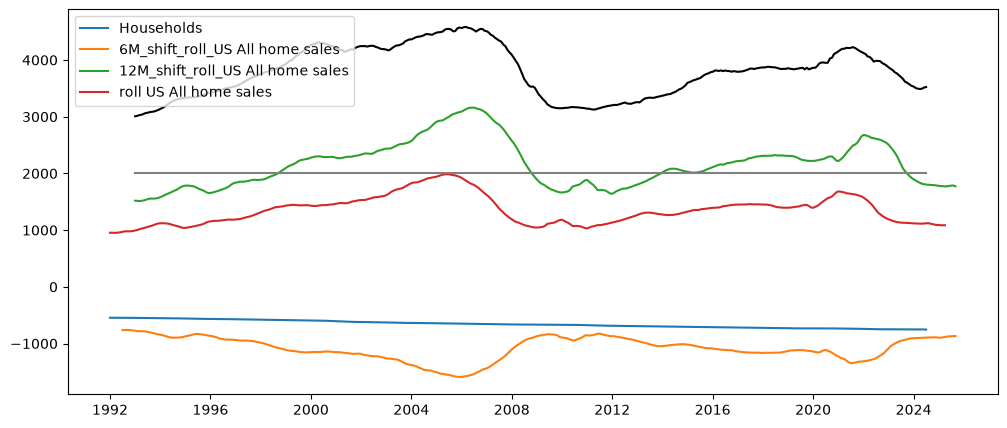

In [81]:
plt.plot(y, color='black')

for i, col in enumerate(x_cols):
    plt.plot(fitted_lin_model.coef_[i] * df[col], label=col)

plt.plot(y*0 + fitted_lin_model.intercept_, color='grey')
plt.legend();

np.float64(0.02930242441587911)

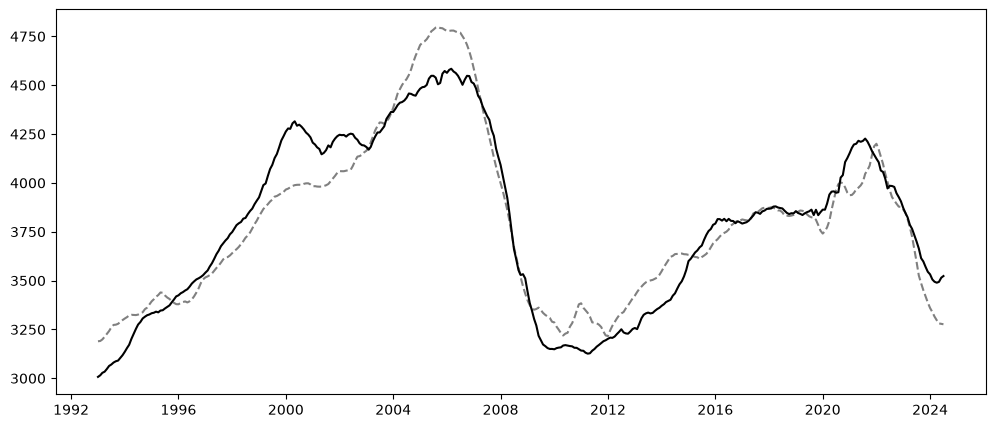

In [82]:
plt.plot(y_hat, color='grey', linestyle='--')
plt.plot(y, color='black')

(np.sqrt(((y_hat - y)**2)) / y).mean()

2.930242441587911 %: average error


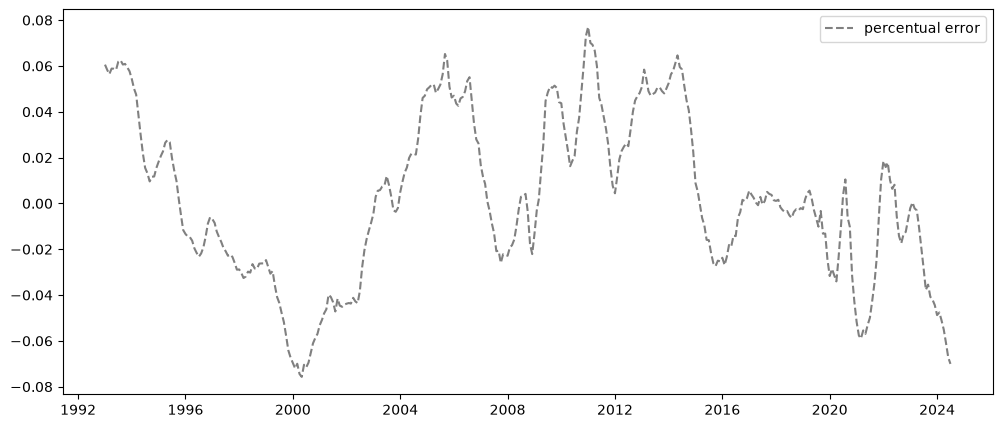

In [83]:
plt.plot((y_hat - y)/y, color='grey', linestyle='--', label='percentual error')
plt.legend()
print((abs((y_hat - y)/y)).mean() * 100, '%: average error')

##### Model - Real Estate market + households

In [84]:
[x for x in df.columns if x.startswith('shift_roll_')]

[]

In [85]:
[x for x in df.columns if 'Real Estate ' in x]

['Real Estate - market sales',
 'diff_Real Estate - market sales',
 'pct_chg_Real Estate - market sales',
 'roll_pct_chg_Real Estate - market sales']

In [86]:
df['shift_roll_Real Estate - market sales'] = df['Real Estate - market sales'].rolling(window=12, min_periods=1, center=True).mean().shift(6)

C:\Users\illoi\AppData\Local\Temp\ipykernel_44248\1045636818.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['shift_roll_Real Estate - market sales'] = df['Real Estate - market sales'].rolling(window=12, min_periods=1, center=True).mean().shift(6)


In [87]:
x_cols = ['Households', 'shift_roll_Real Estate - market sales']
# x_cols = ['shift_roll_Real Estate - market sales']
aux_df = df[x_cols + ['Y']].dropna()

X = aux_df[x_cols]
y = aux_df['Y']

fitted_lin_model = LinearRegression().fit(X, y)

In [88]:
fitted_lin_model.coef_

array([4.05198513e-05, 2.17256622e-09])

In [89]:
fitted_lin_model.intercept_

np.float64(-304.0518918443249)

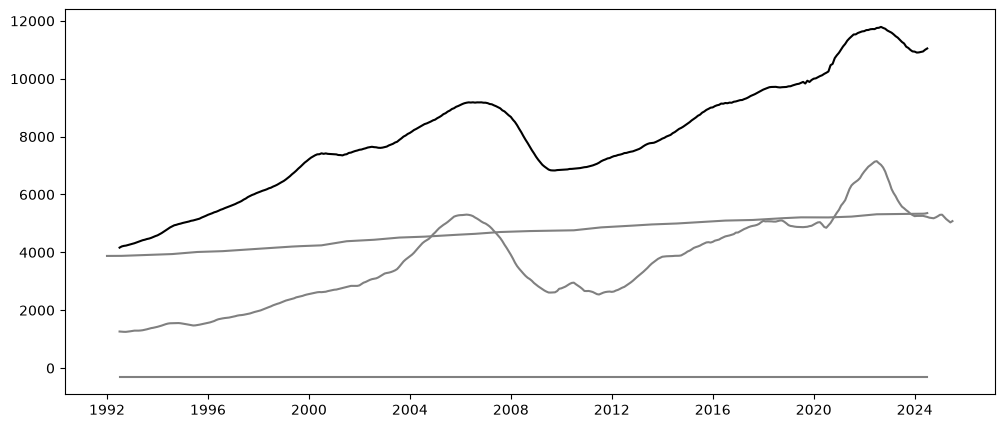

In [90]:
plt.plot(y, color='black')

for i, col in enumerate(x_cols):
    plt.plot(fitted_lin_model.coef_[i] * df[col], color='grey')

plt.plot(y*0 + fitted_lin_model.intercept_, color='grey')

np.float64(0.041702151038585066)

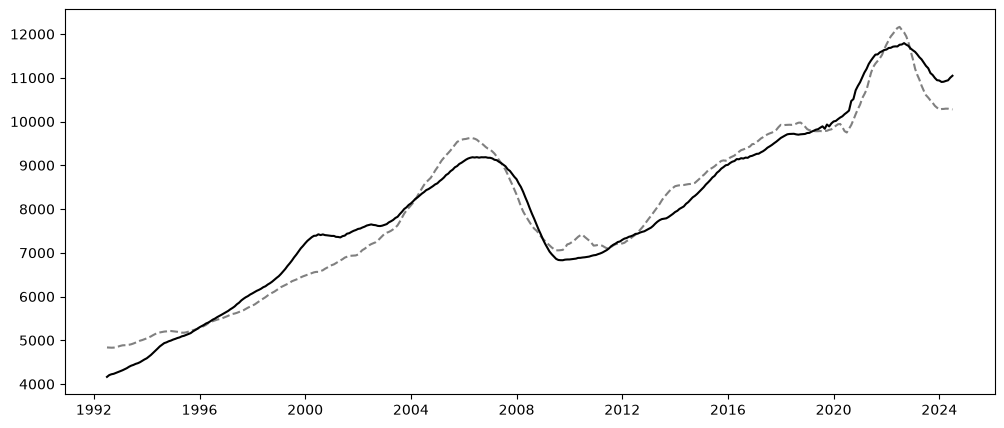

In [91]:
y_hat = (fitted_lin_model.coef_ * aux_df[x_cols]).sum(axis=1) + fitted_lin_model.intercept_

plt.plot(y_hat, color='grey', linestyle='--')
plt.plot(y, color='black')

(np.sqrt(((y_hat - y)**2)) / y).mean()

##### Other

In [92]:
# [x for x in df.columns if 'US' in x]

PearsonRResult(statistic=np.float64(0.42531684875577613), pvalue=np.float64(9.684307966426764e-19))

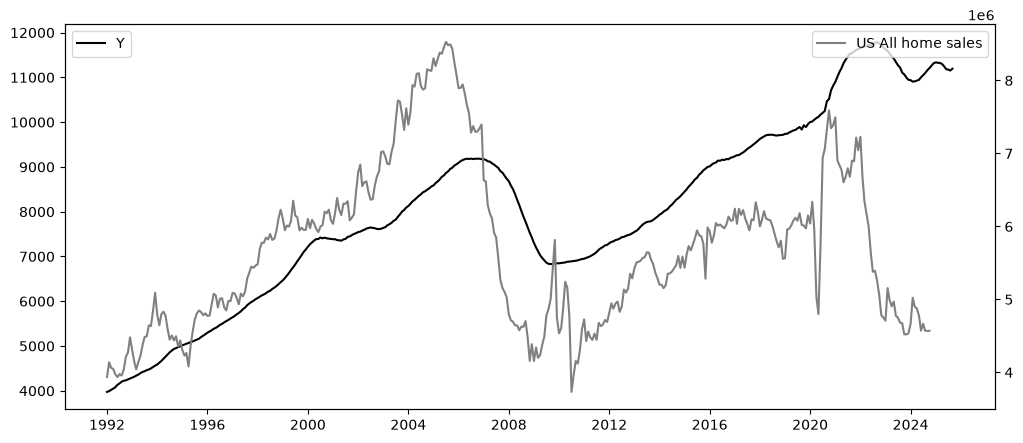

In [93]:
dual_plot_corr(df['Y'], df['US All home sales'])

In [94]:
df['Y'].corr(df['US All home sales'])

np.float64(0.4253168487557759)

In [95]:
df['Y'].corr(df['Employees_share_population'])

np.float64(0.4190070266579163)

In [96]:
df['Y'].diff().corr(df['Employees_share_population'].diff())

np.float64(0.10908321981764611)

In [97]:
df['Y'].autocorr()

np.float64(0.9997866061311528)

In [98]:
df['Y'].diff().autocorr()

np.float64(0.7999354568951806)

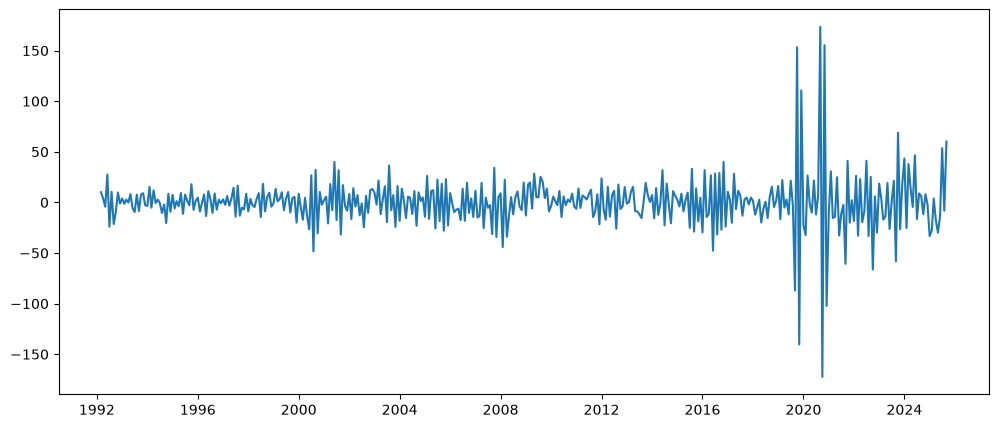

In [99]:
plt.plot(df['Y'].diff().diff())

In [100]:
df['Y'].diff().diff().autocorr()

np.float64(-0.6764780909585663)

<Axes: >

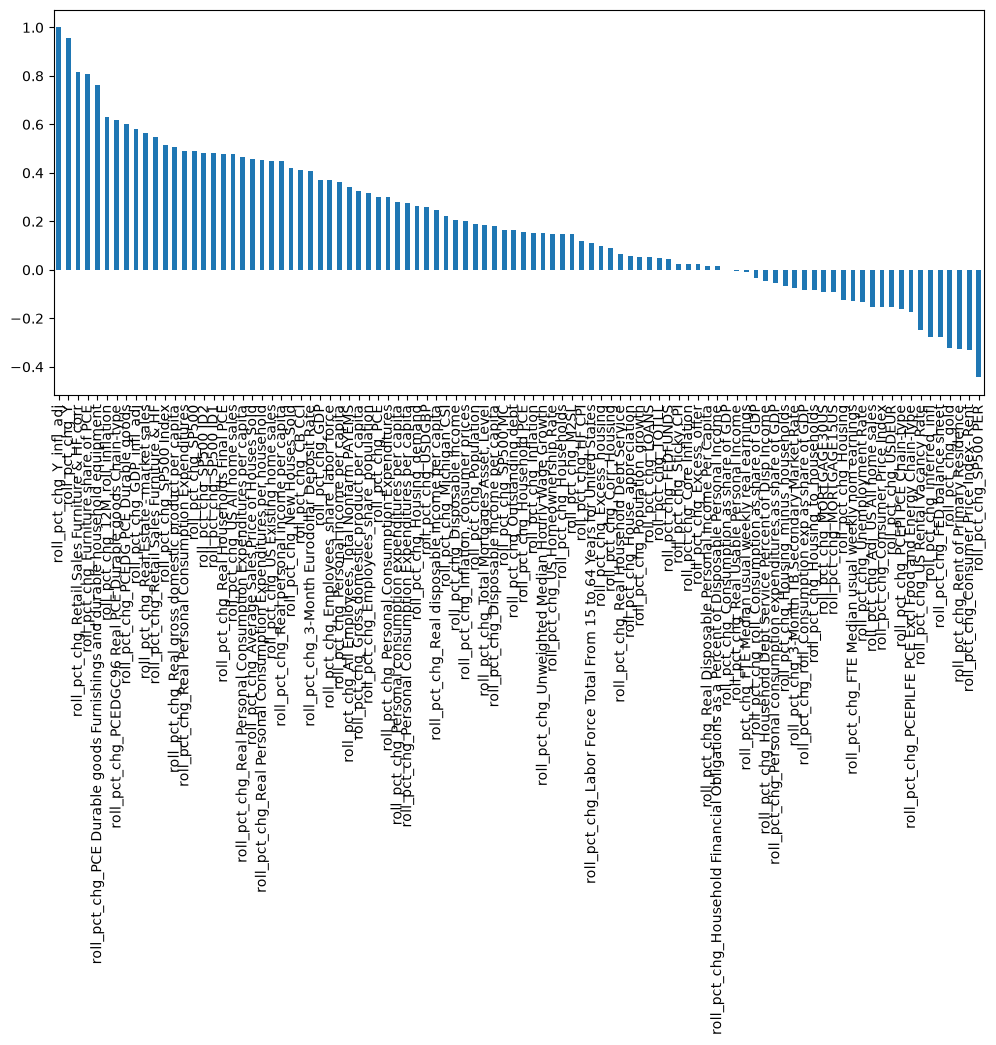

In [101]:
roll_pct_chg_original_columns_ampl = list('roll_pct_chg_' + original_cols)
corrs = df[roll_pct_chg_original_columns_ampl].corr()['roll_pct_chg_Y_infl_adj'].sort_values(ascending=False)
corrs.plot(kind='bar')

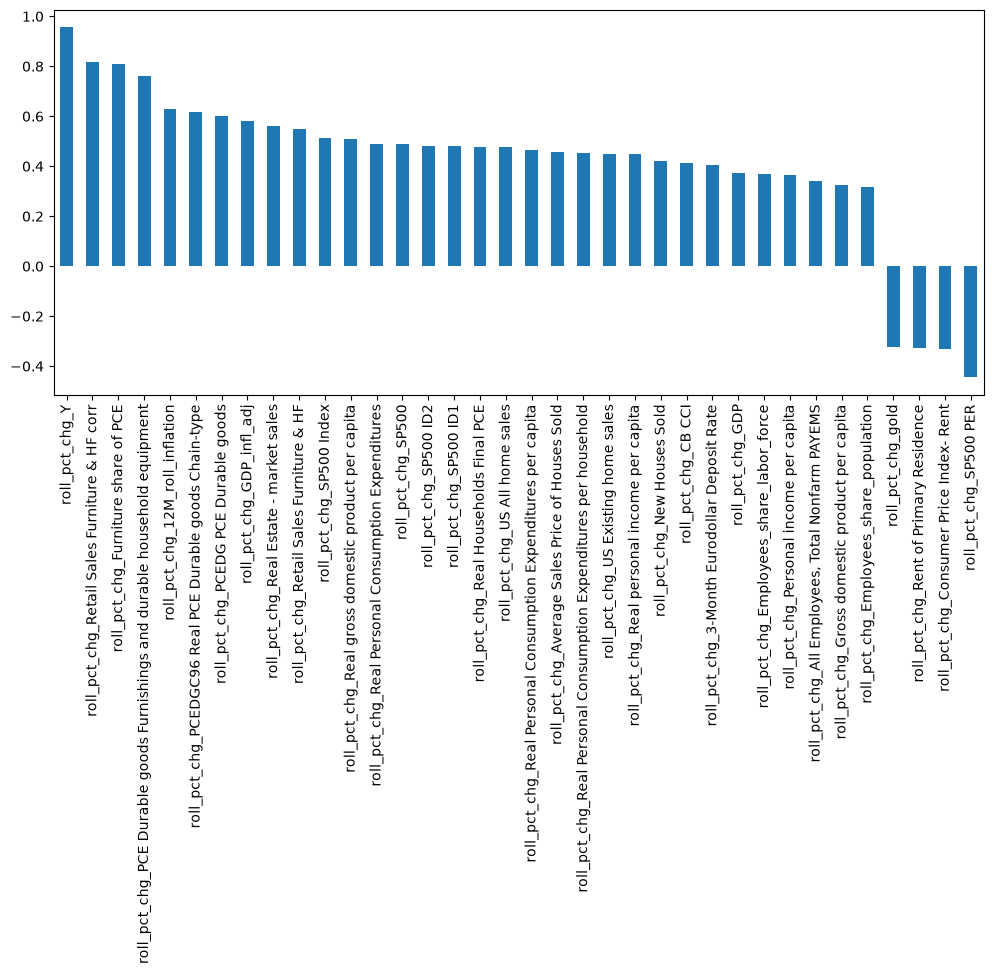

In [102]:
roll_pct_chg_relevant_vars = list(corrs[(abs(corrs)>0.3) & (corrs<1)].index)
corrs[roll_pct_chg_relevant_vars].sort_values(ascending=False).plot(kind='bar')
roll_pct_chg_relevant_vars = corrs[roll_pct_chg_relevant_vars].sort_values(ascending=False).index
relevant_vars = [x.replace('roll_pct_chg_','') for x in roll_pct_chg_relevant_vars]

PearsonRResult(statistic=np.float64(-0.1729983282921702), pvalue=np.float64(0.0005018880562445298))

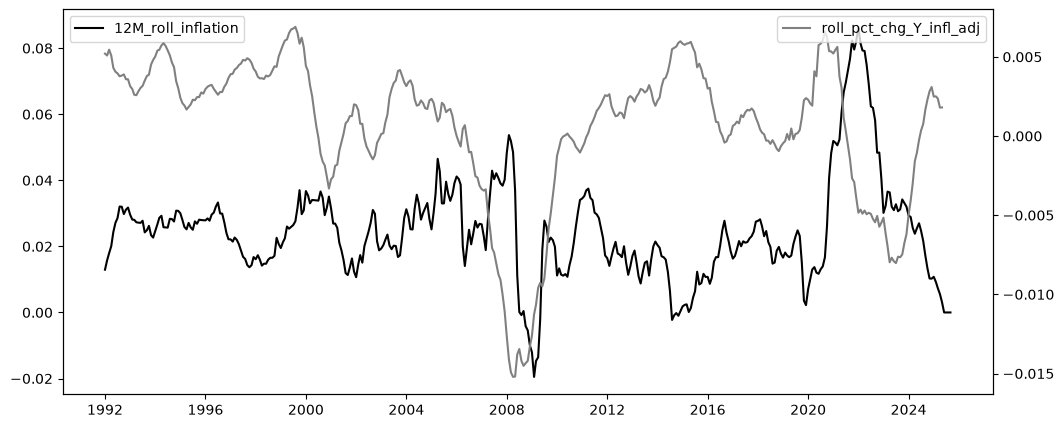

In [103]:
dual_plot_corr(df['12M_roll_inflation'], df['roll_pct_chg_Y_infl_adj'])

PearsonRResult(statistic=np.float64(0.08733893924693052), pvalue=np.float64(0.08298195637337784))

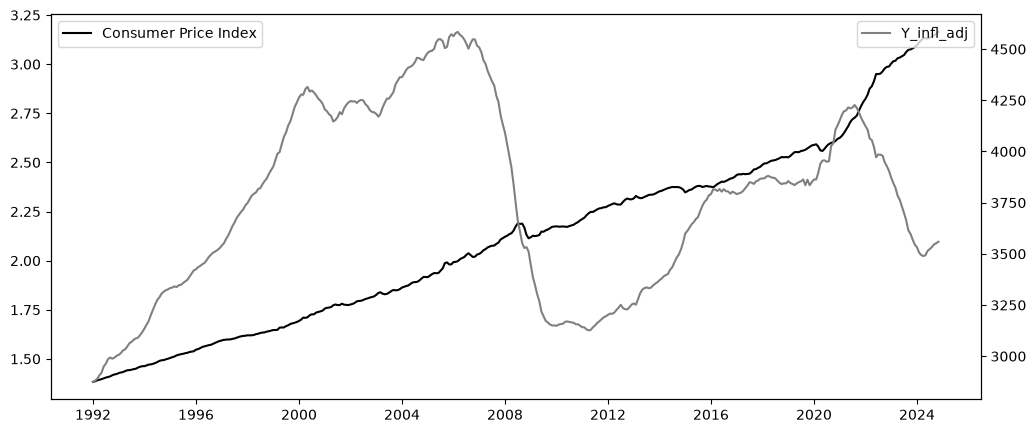

In [104]:
dual_plot_corr(df['Consumer Price Index'], df['Y_infl_adj'])

In [105]:
# model_cols = ['Real Estate - market sales', 'Real gross domestic product per capita', 'SP500', 'All Employees, Total Nonfarm PAYEMS']
model_cols = ['US All home sales', 'Real gross domestic product per capita', 'SP500', 'All Employees, Total Nonfarm PAYEMS']
roll_pct_chg_model_cols = ['roll_pct_chg_' + x for x in model_cols]

<Axes: >

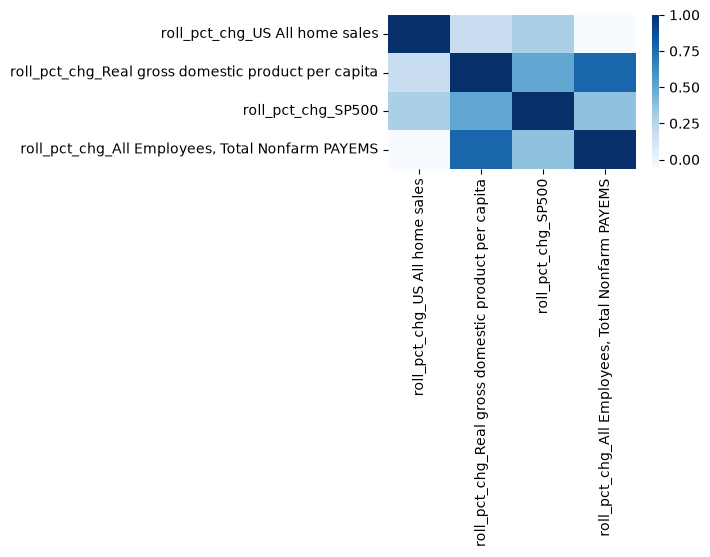

In [106]:
plt.figure(figsize=(4,2))
sns.heatmap(df[roll_pct_chg_model_cols].corr(), cmap='Blues')
# plt.tight_layout()

In [107]:
model_cols = model_cols + ['Households', '12M_shift_roll_US All home sales', 'roll US All home sales']

x_cols = model_cols
# x_cols = ['shift_roll_Real Estate - market sales']
aux_df = df[x_cols + ['Y_infl_adj']].dropna()

X = aux_df[x_cols]
y = aux_df['Y_infl_adj']

fitted_lin_model = LinearRegression().fit(X, y)

np.float64(0.025975800277970956)

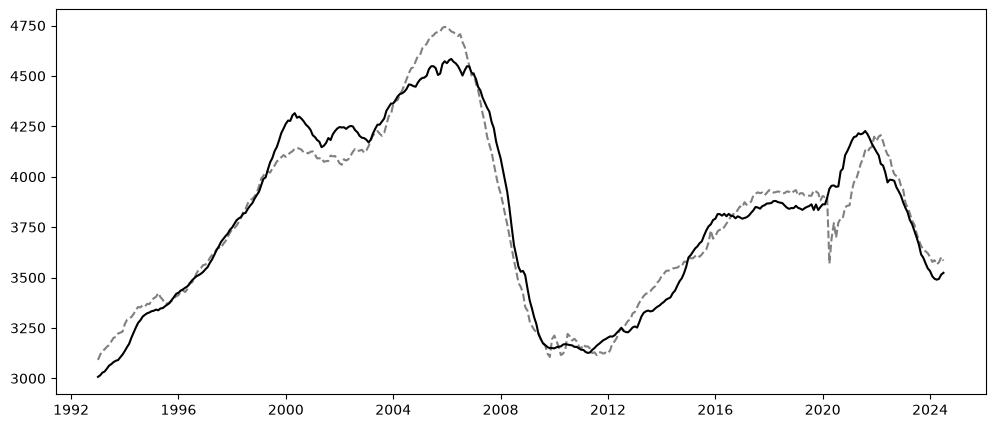

In [108]:
y_hat = (fitted_lin_model.coef_ * aux_df[model_cols]).sum(axis=1) + fitted_lin_model.intercept_

plt.plot(y_hat, color='grey', linestyle='--')
plt.plot(y, color='black')

np.sqrt(((y_hat - y)**2).mean()) / y.mean()

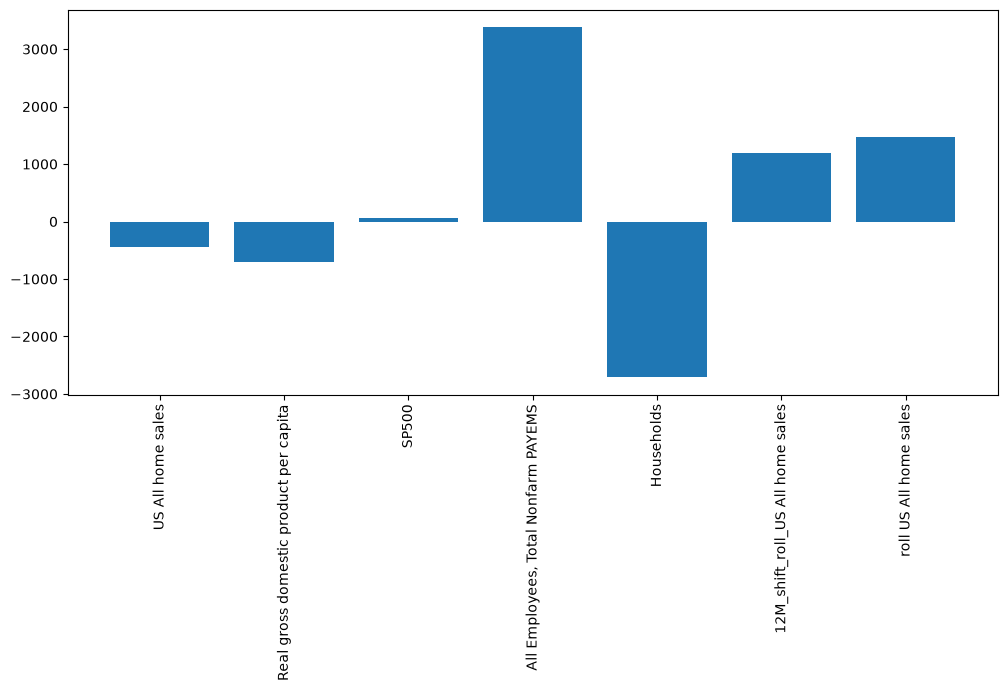

In [109]:
plt.bar(x=model_cols, height=fitted_lin_model.coef_ * aux_df[model_cols].mean())
# plt.xticks(rotation=90);
plt.tick_params(axis='x', labelrotation=90);

##### Other - NO RE

C:\Users\illoi\AppData\Local\Temp\ipykernel_44248\1952914808.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Y_infl_adj-NO_RE'] = (df['Y_infl_adj'] - 6500/f * df['12M_shift_roll_US All home sales'])
C:\Users\illoi\AppData\Local\Temp\ipykernel_44248\1952914808.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['roll_pct_chg_Y_infl_adj-NO_RE'] = df['Y_infl_adj-NO_RE'].pct_change(fill_method=None).rolling(window=12, min_periods=1, center=True).mean()


<Axes: >

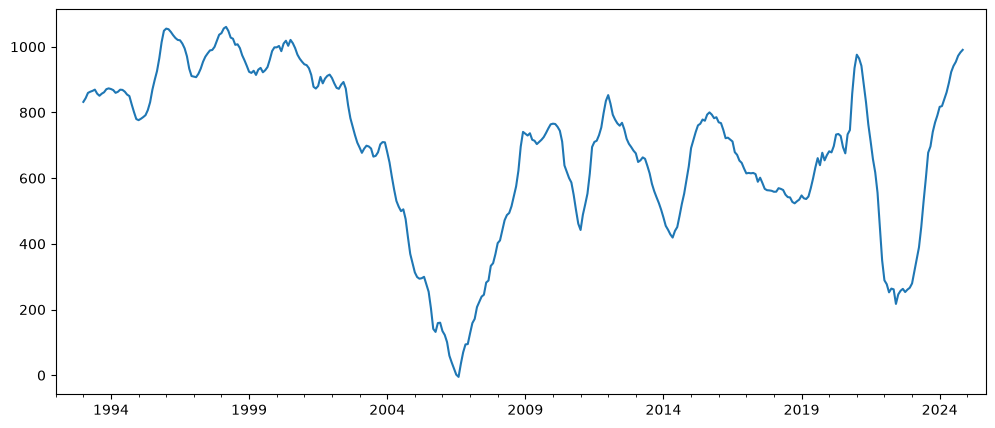

In [110]:
df['Y_infl_adj-NO_RE'] = (df['Y_infl_adj'] - 6500/f * df['12M_shift_roll_US All home sales'])
df['roll_pct_chg_Y_infl_adj-NO_RE'] = df['Y_infl_adj-NO_RE'].pct_change(fill_method=None).rolling(window=12, min_periods=1, center=True).mean()
df['Y_infl_adj-NO_RE'].plot()

In [111]:
original_columns_ampl = list(original_cols) + ['Y_infl_adj-NO_RE']
# sns.heatmap(df[original_columns_ampl].corr(), cmap='Blues')

<Axes: >

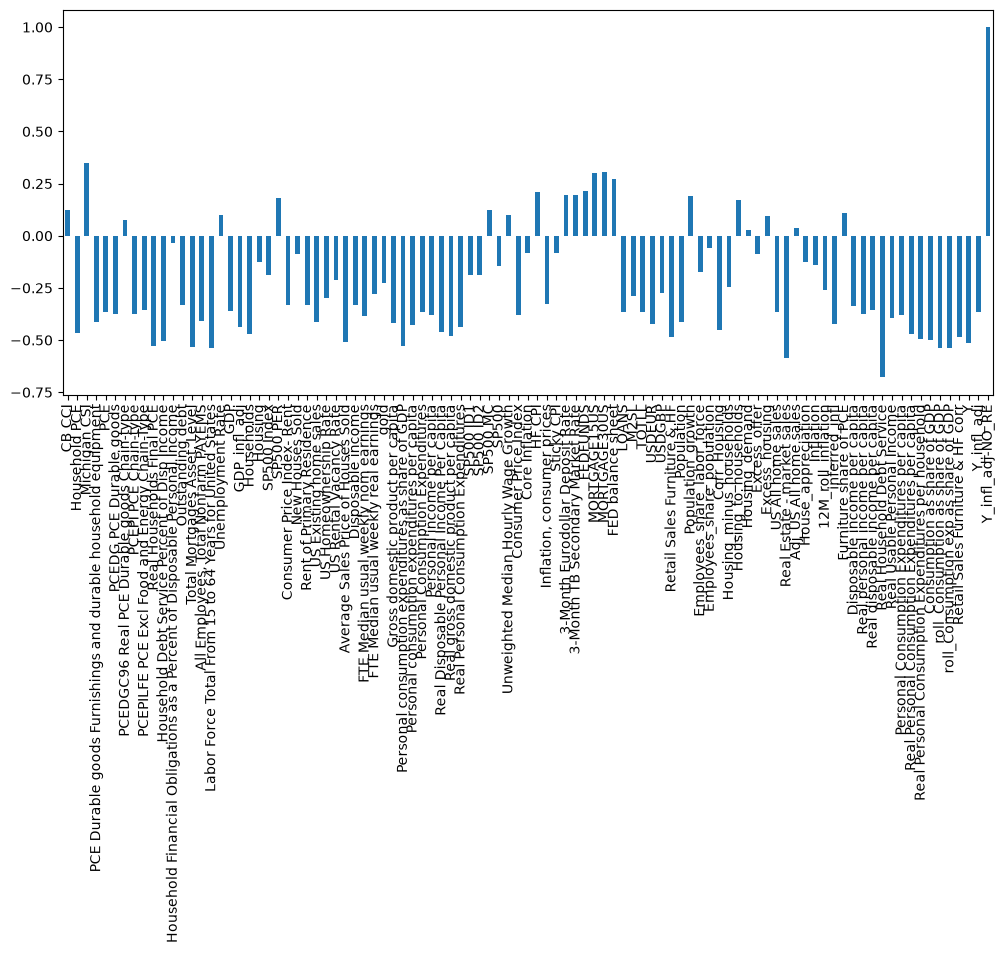

In [112]:
df[original_columns_ampl].corr()['Y_infl_adj-NO_RE'].plot(kind='bar')

<Axes: >

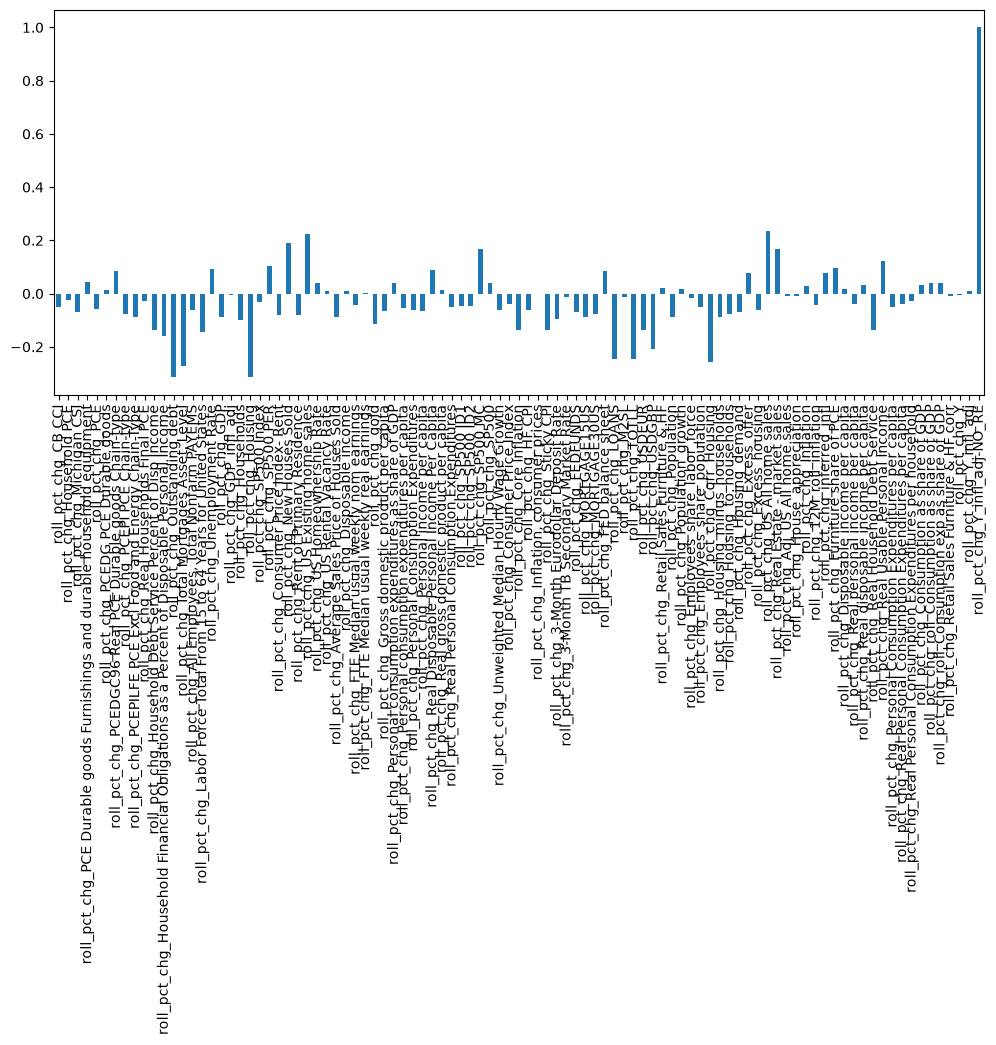

In [114]:
roll_pct_chg_original_columns_ampl = list('roll_pct_chg_' + original_cols) + ['roll_pct_chg_Y_infl_adj-NO_RE']
df[roll_pct_chg_original_columns_ampl].corr()['roll_pct_chg_Y_infl_adj-NO_RE'].plot(kind='bar')

C:\Users\illoi\AppData\Local\Temp\ipykernel_44248\789216641.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['roll_Av House Price-infl_adj'] = df['Average Sales Price of Houses Sold'].rolling(window=12, min_periods=1, center=True).mean() / df['Consumer Price Index']


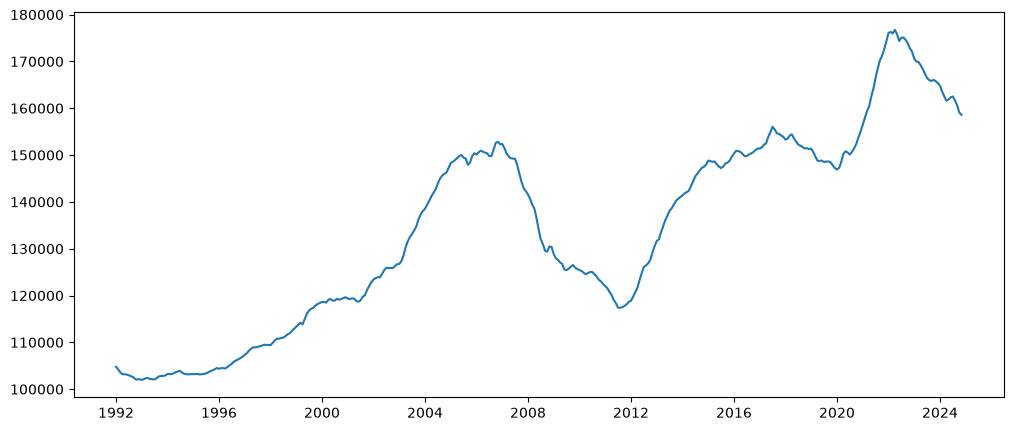

In [115]:
df['roll_Av House Price-infl_adj'] = df['Average Sales Price of Houses Sold'].rolling(window=12, min_periods=1, center=True).mean() / df['Consumer Price Index']

plt.plot(df['roll_Av House Price-infl_adj'])

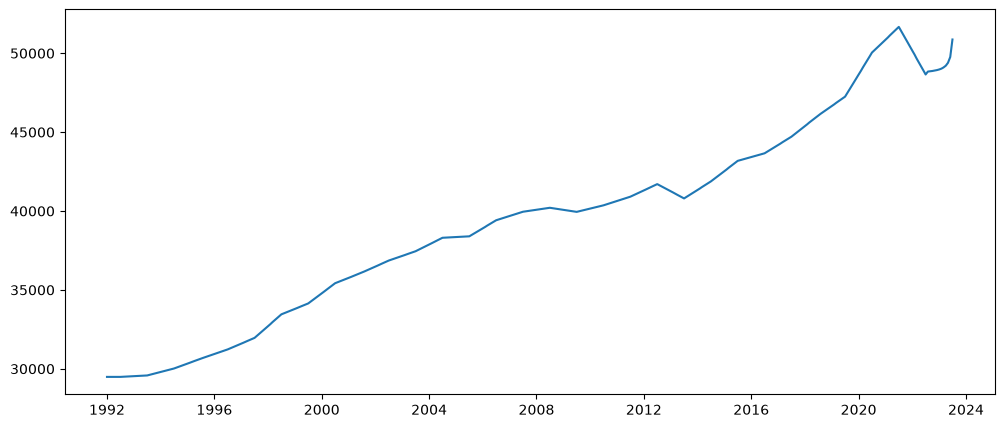

In [116]:
plt.plot(df['Real Disposable Personal Income Per Capita'].rolling(window=12, min_periods=1, center=True).mean())

##### Other 3

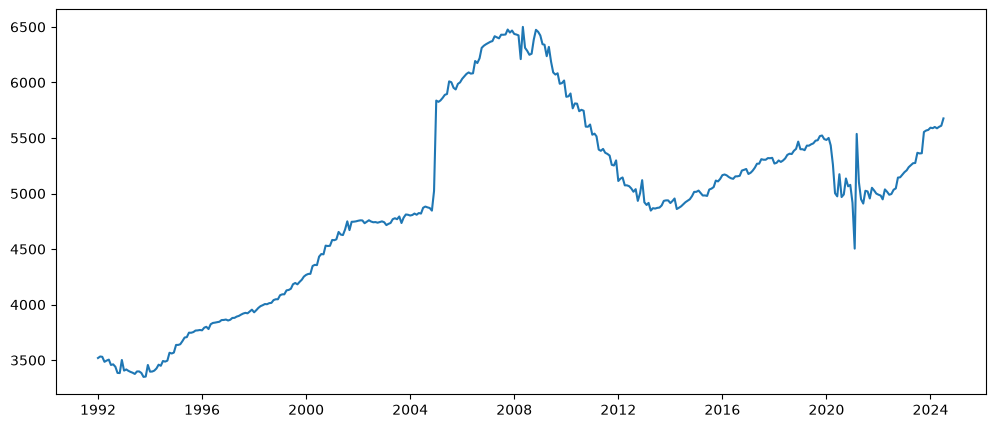

In [117]:
plt.plot(df['Real Household Debt Service'])

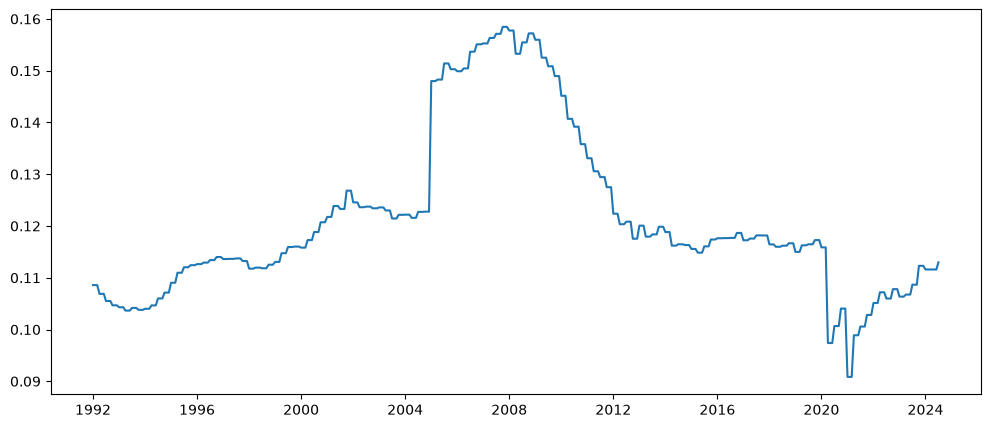

In [118]:
plt.plot(df['Household Debt Service Percent of Disp Income'])